In [13]:
from pathlib import Path
DATA_ROOT = Path("indoor-location-competition-20/data")
OUTPUT_ROOT = Path("output_ibeacon")
SITES = None
FLOORS = None
BEACON = None
SITE_WIDE_BEACON = True
CELL_M = 2.0
GRID_STEP_M = 0.75
RADIUS_M = 6.0
K_NEIGHBORS = 6
MIN_NEIGHBORS = 2
IDW_POWER = 2.0
MAX_GAP_MS = 5000
RSSI_LOWER_PERCENTILE = 2.0
RSSI_UPPER_PERCENTILE = 98.0
TOP_N = 15
MAX_PATHS_PLOT = 12
SHOW_FLOORPLAN = True
SKIP_FAILED_FLOORS = True

In [14]:
from __future__ import annotations
import argparse
import json
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

In [15]:
def parse_trace(path: Path, max_gap_ms: float, min_rssi=None, max_rssi=None):
    waypoints, scans = [], []
    malformed = 0
    with path.open('r', encoding='utf-8-sig', errors='replace') as handle:
        for line in handle:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split('\t')
            if len(parts) < 2:
                continue
            typ = parts[1]
            try:
                if typ == 'TYPE_WAYPOINT' and len(parts) >= 4:
                    waypoints.append((float(parts[0]), float(parts[2]), float(parts[3])))
                elif typ == 'TYPE_BEACON' and len(parts) >= 7:
                    beacon_id = '_'.join((parts[2].strip().upper(), parts[3].strip(), parts[4].strip()))
                    scans.append((float(parts[0]), beacon_id, float(parts[6])))
            except (ValueError, IndexError):
                malformed += 1
    cols = ['timestamp_ms', 'beacon_id', 'rssi_dbm', 'x_m', 'y_m', 'path_id', 'nearest_waypoint_gap_ms']
    if not waypoints or not scans:
        return pd.DataFrame(columns=cols), {'waypoints': len(waypoints), 'scans': len(scans), 'kept': 0, 'malformed': malformed}
    wp = np.asarray(waypoints, dtype=float)
    wp = wp[np.argsort(wp[:, 0], kind='stable')]
    wpd = pd.DataFrame(wp, columns=['t', 'x', 'y']).groupby('t', as_index=False)[['x', 'y']].mean()
    wpt = wpd['t'].to_numpy()
    x = wpd['x'].to_numpy()
    y = wpd['y'].to_numpy()
    scan = pd.DataFrame(scans, columns=['timestamp_ms', 'beacon_id', 'rssi_dbm'])
    # Only drop non-finite RSSI here. Color-range percentiles do NOT filter data.
    scan = scan[np.isfinite(scan['rssi_dbm'])].copy()
    if min_rssi is not None:
        scan = scan[scan['rssi_dbm'] >= min_rssi].copy()
    if max_rssi is not None:
        scan = scan[scan['rssi_dbm'] <= max_rssi].copy()
    if not len(scan):
        return pd.DataFrame(columns=cols), {'waypoints': len(wp), 'scans': len(scans), 'kept': 0, 'malformed': malformed}
    t = scan['timestamp_ms'].to_numpy()
    idx = np.searchsorted(wpt, t, side='left')
    il = np.clip(idx - 1, 0, len(wpt) - 1)
    ir = np.clip(idx, 0, len(wpt) - 1)
    near = np.minimum(np.abs(t - wpt[il]), np.abs(t - wpt[ir]))
    keep = (t >= wpt[0]) & (t <= wpt[-1]) & (near <= max_gap_ms)
    scan = scan.loc[keep].copy()
    t = scan['timestamp_ms'].to_numpy()
    scan['x_m'] = np.interp(t, wpt, x)
    scan['y_m'] = np.interp(t, wpt, y)
    scan['path_id'] = path.stem
    scan['nearest_waypoint_gap_ms'] = near[keep]
    return scan[cols], {'waypoints': len(wp), 'scans': len(scans), 'kept': len(scan), 'malformed': malformed}

In [16]:
def collect(folder: Path, max_gap_ms: float, min_rssi=None, max_rssi=None):
    paths = sorted((folder / 'path_data_files').glob('*.txt'))
    if not paths:
        raise FileNotFoundError(f'No *.txt traces found in {folder / "path_data_files"}')
    frames, diagnostics = [], []
    for path in paths:
        data, info = parse_trace(path, max_gap_ms, min_rssi, max_rssi)
        info['path_id'] = path.stem
        diagnostics.append(info)
        if not data.empty:
            frames.append(data)
    if not frames:
        raise RuntimeError('No usable iBeacon scans matched waypoints. Check the floor and --max-gap-ms.')
    return pd.concat(frames, ignore_index=True), pd.DataFrame(diagnostics)

In [17]:
def spatial_bins(df: pd.DataFrame, cell_m: float, origin):
    tmp = df.copy()
    tmp['ix'] = np.floor((tmp['x_m'] - origin[0]) / cell_m).astype(int)
    tmp['iy'] = np.floor((tmp['y_m'] - origin[1]) / cell_m).astype(int)
    agg = tmp.groupby(['ix', 'iy'], as_index=False).agg(
        median_rssi=('rssi_dbm', 'median'), mean_rssi=('rssi_dbm', 'mean'),
        std_rssi=('rssi_dbm', 'std'), count=('rssi_dbm', 'size'),
        n_paths=('path_id', 'nunique'))
    agg['x_m'] = origin[0] + (agg['ix'] + 0.5) * cell_m
    agg['y_m'] = origin[1] + (agg['iy'] + 0.5) * cell_m
    return agg

In [18]:
def make_grid(bins, cell_m: float, k=6, radius_m=6., power=2., min_neighbors=2, grid_step_m=0.75):
    xy = bins[['x_m', 'y_m']].to_numpy(dtype=float)
    values = bins['median_rssi'].to_numpy(float)
    gx = np.arange(xy[:, 0].min(), xy[:, 0].max() + grid_step_m / 2, grid_step_m)
    gy = np.arange(xy[:, 1].min(), xy[:, 1].max() + grid_step_m / 2, grid_step_m)
    xx, yy = np.meshgrid(gx, gy)
    query = np.c_[xx.ravel(), yy.ravel()]
    tree = cKDTree(xy)
    kk = min(int(k), len(xy))
    dist, ix = tree.query(query, k=kk, distance_upper_bound=radius_m)
    dist = np.atleast_2d(dist) if kk == 1 else dist
    ix = np.atleast_2d(ix) if kk == 1 else ix
    if kk == 1:
        dist, ix = dist.T, ix.T
    valid = np.isfinite(dist) & (ix < len(values))
    safe_index = np.where(valid, ix, 0)
    weights = np.where(valid, 1. / np.maximum(dist, 1e-6) ** power, 0.)
    den = weights.sum(axis=1)
    z = np.full(len(query), np.nan)
    acceptable = (valid.sum(axis=1) >= min_neighbors) & (den > 0)
    z[acceptable] = (weights * values[safe_index]).sum(axis=1)[acceptable] / den[acceptable]
    return xx, yy, z.reshape(xx.shape)

In [19]:
def save_figure(fig, folder: Path, name):
    fig.savefig(folder / f'{name}.png', dpi=220, bbox_inches='tight')
    plt.close(fig)

In [20]:
def adaptive_rssi_limits(values, lower=2.0, upper=98.0):
    z = np.asarray(values, dtype=float)
    z = z[np.isfinite(z)]
    if len(z) == 0:
        raise ValueError('No finite RSSI observations for adaptive color limits.')
    if not (0 <= lower < upper <= 100):
        raise ValueError('RSSI percentiles must satisfy 0 <= lower < upper <= 100.')
    lo, hi = np.percentile(z, [lower, upper])
    if np.isclose(lo, hi):
        lo, hi = float(np.min(z)), float(np.max(z))
    if np.isclose(lo, hi):
        lo, hi = float(lo) - 1.0, float(hi) + 1.0
    return float(lo), float(hi)


def plot_floor_background(ax, floor_folder, alpha=0.5):
    floor_folder = Path(floor_folder)
    image_path = floor_folder / 'floor_image.png'
    info_path = floor_folder / 'floor_info.json'
    if not image_path.is_file() or not info_path.is_file():
        warnings.warn(f'Floor overlay not available for {floor_folder}: '
                      f'missing floor_image.png or floor_info.json')
        return False
    try:
        info = json.loads(info_path.read_text(encoding='utf-8'))
        info = info.get('map_info', info)
        width, height = float(info['width']), float(info['height'])
        if not (np.isfinite(width) and np.isfinite(height) and width > 0 and height > 0):
            raise ValueError('Invalid floor dimensions')
        image = plt.imread(image_path)
        ax.imshow(image, extent=(0, width, 0, height), origin='upper',
                  alpha=alpha, zorder=-10, interpolation='nearest')
        ax.set_xlim(0, width)
        ax.set_ylim(0, height)
        return True
    except (KeyError, ValueError, TypeError, OSError) as error:
        warnings.warn(f'Unable to load floor overlay for {floor_folder}: {error}')
        return False

In [21]:
def plots(df, all_data, bins, summary, args, folder, out):
    beacon = str(df['beacon_id'].iloc[0]); title = f'{args.site}/{args.floor} | {beacon}'
    rmin, rmax = adaptive_rssi_limits(df.rssi_dbm, args.rssi_lower_percentile, args.rssi_upper_percentile)
    # Figure 00: separate floor-plan overlay (only this plot has a background image).
    if args.floorplan:
        fig, ax = plt.subplots(figsize=(10, 8))
        if plot_floor_background(ax, folder, alpha=0.70):
            dots = ax.scatter(df.x_m, df.y_m, c=df.rssi_dbm, cmap='turbo',
                              vmin=rmin, vmax=rmax, s=9, alpha=.70, zorder=5)
            ax.set(title=f'00 Raw iBeacon RSSI on floor plan\n{title}',
                   xlabel='X (m)', ylabel='Y (m)', aspect='equal')
            fig.colorbar(dots, ax=ax, label='RSSI (dBm; adaptive scale)')
            save_figure(fig, out, '00_raw_rssi_floorplan_overlay')
        else:
            (out / '00_raw_rssi_floorplan_overlay.png').unlink(missing_ok=True)
            plt.close(fig)
    else:
        (out / '00_raw_rssi_floorplan_overlay.png').unlink(missing_ok=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    dots = ax.scatter(df.x_m, df.y_m, c=df.rssi_dbm, cmap='turbo', vmin=rmin, vmax=rmax, s=9, alpha=.70, zorder=5)
    ax.set(title=f'01 Raw iBeacon RSSI observations\n{title}', xlabel='X (m)', ylabel='Y (m)', aspect='equal')
    fig.colorbar(dots, ax=ax, label=f'RSSI (dBm; {args.rssi_lower_percentile:g}th–{args.rssi_upper_percentile:g}th percentile display)')
    save_figure(fig, out, '01_raw_rssi_scatter')
    fig, ax = plt.subplots(figsize=(10, 8))
    dots = ax.scatter(bins.x_m, bins.y_m, c=bins.median_rssi, cmap='turbo', vmin=rmin, vmax=rmax,
                      s=np.clip(30 + 22 * np.sqrt(bins['count']), 30, 300), marker='s', linewidths=0, alpha=.80, zorder=5)
    ax.set(title=f'02 Observed-cell median RSSI ({args.cell_m:g} m cells)\n{title}', xlabel='X (m)', ylabel='Y (m)', aspect='equal')
    fig.colorbar(dots, ax=ax, label='Median RSSI (dBm)')
    save_figure(fig, out, '02_observed_cell_median')
    if len(bins) >= args.min_neighbors:
        xx, yy, surface = make_grid(bins, args.cell_m, args.k_neighbors, args.radius_m,
                                     args.idw_power, args.min_neighbors, args.grid_step_m)
        fig, ax = plt.subplots(figsize=(10, 8))
        if np.isfinite(surface).any():
            mesh = ax.pcolormesh(xx, yy, np.ma.masked_invalid(surface), shading='auto', cmap='turbo',
                                 vmin=rmin, vmax=rmax, alpha=.75)
            fig.colorbar(mesh, ax=ax, label='Estimated RSSI (dBm)')
        ax.scatter(bins.x_m, bins.y_m, s=3, c='black', alpha=.25, label='Observed cells', zorder=6)
        ax.set(title=f'03 IDW RSSI heatmap (radius ≤ {args.radius_m:g}m)\n{title}', xlabel='X (m)', ylabel='Y (m)', aspect='equal')
        ax.legend(loc='best')
        save_figure(fig, out, '03_idw_heatmap')
        if np.isfinite(surface).any():
            pd.DataFrame({'x_m': xx.ravel(), 'y_m': yy.ravel(), 'idw_rssi_dbm': surface.ravel()}).to_csv(out / 'idw_grid.csv', index=False)
    fig, ax = plt.subplots(figsize=(10, 8))
    dots = ax.scatter(bins.x_m, bins.y_m, c=bins['count'], cmap='viridis', marker='s', s=110)
    ax.set(title=f'04 Measurements per observed cell\n{title}', xlabel='X (m)', ylabel='Y (m)', aspect='equal')
    fig.colorbar(dots, ax=ax, label='Number of scans')
    save_figure(fig, out, '04_spatial_measurement_density')
    std = bins.dropna(subset=['std_rssi'])
    if not std.empty:
        fig, ax = plt.subplots(figsize=(10, 8))
        dots = ax.scatter(std.x_m, std.y_m, c=std.std_rssi, cmap='magma', marker='s', s=110)
        ax.set(title=f'05 Within-cell RSSI standard deviation\n{title}', xlabel='X (m)', ylabel='Y (m)', aspect='equal')
        fig.colorbar(dots, ax=ax, label='Standard deviation (dB)')
        save_figure(fig, out, '05_spatial_variability')
    fig, ax = plt.subplots(figsize=(9, 5))
    data_min, data_max = df.rssi_dbm.min(), df.rssi_dbm.max()
    hist_bins = np.arange(np.floor(data_min) - 1.5, np.ceil(data_max) + 4.5, 3)
    ax.hist(df.rssi_dbm, bins=hist_bins, alpha=.65, label='Raw scans')
    ax.axvline(rmin, c='tab:orange', ls=':', label=f'Display P{args.rssi_lower_percentile:g}: {rmin:.1f}')
    ax.axvline(rmax, c='tab:red', ls=':', label=f'Display P{args.rssi_upper_percentile:g}: {rmax:.1f}')
    ax.axvline(df.rssi_dbm.median(), c='black', ls='--', label=f'Raw median {df.rssi_dbm.median():.1f} dBm')
    ax.set(title='06 RSSI distribution', xlabel='RSSI (dBm)', ylabel='Number of scans')
    ax.legend(); save_figure(fig, out, '06_rssi_histogram')
    fig, ax = plt.subplots(figsize=(11, 6))
    for _, group in list(df.groupby('path_id'))[:args.max_paths_plot]:
        ordered = group.sort_values('timestamp_ms')
        t = (ordered.timestamp_ms - ordered.timestamp_ms.iloc[0]) / 1000
        ax.plot(t, ordered.rssi_dbm, '.', ms=3, alpha=.50)
    ax.set(title=f'07 RSSI against elapsed time (first {args.max_paths_plot} paths)', xlabel='Seconds since trace start', ylabel='RSSI (dBm)')
    save_figure(fig, out, '07_rssi_over_time')
    for obsolete in ('08_beacon_frequency.png', '09_median_vs_mean.png'):
        (out / obsolete).unlink(missing_ok=True)

In [22]:
def main(argv=None):
    p = argparse.ArgumentParser(description=__doc__)
    p.add_argument('--data-root', type=Path, required=True, help='Directory containing site1/ and site2/')
    p.add_argument('--site', default='site1'); p.add_argument('--floor', default='F1')
    p.add_argument('--beacon', default=None, help='Exact UUID_MAJOR_MINOR beacon ID; default: most paths, then most scans')
    p.add_argument('--output-root', type=Path, default=Path('output_ibeacon'))
    p.add_argument('--max-gap-ms', type=float, default=5000, help='Maximum distance to nearest waypoint timestamp')
    p.add_argument('--min-rssi', type=float, default=None, help='Optional raw RSSI lower filtering threshold (off by default)')
    p.add_argument('--max-rssi', type=float, default=None, help='Optional raw RSSI upper filtering threshold (off by default)')
    p.add_argument('--rssi-lower-percentile', type=float, default=2.0)
    p.add_argument('--rssi-upper-percentile', type=float, default=98.0)
    p.add_argument('--cell-m', type=float, default=2.0)
    p.add_argument('--grid-step-m', type=float, default=0.75)
    p.add_argument('--radius-m', type=float, default=6.0)
    p.add_argument('--k-neighbors', type=int, default=6)
    p.add_argument('--min-neighbors', type=int, default=2)
    p.add_argument('--idw-power', type=float, default=2.0)
    p.add_argument('--top-n', type=int, default=15)
    p.add_argument('--max-paths-plot', type=int, default=12)
    p.add_argument('--floorplan', action='store_true', help='Overlay floor_image.png using floor_info.json coordinates')
    args = p.parse_args(argv)
    if args.cell_m <= 0 or args.grid_step_m <= 0 or args.radius_m <= 0 or args.k_neighbors < 1 or args.min_neighbors < 1:
        p.error('Cell, grid, radius and neighbor settings must be positive.')
    if args.min_rssi is not None and args.max_rssi is not None and args.min_rssi >= args.max_rssi:
        p.error('--min-rssi must be smaller than --max-rssi')
    if not (0 <= args.rssi_lower_percentile < args.rssi_upper_percentile <= 100):
        p.error('RSSI percentiles must satisfy 0 <= lower < upper <= 100')
    floor = args.data_root / args.site / args.floor
    if not floor.is_dir():
        raise FileNotFoundError(f'Missing floor folder: {floor}')
    out = args.output_root / args.site / args.floor
    out.mkdir(parents=True, exist_ok=True)
    all_data, diagnostics = collect(floor, args.max_gap_ms, args.min_rssi, args.max_rssi)
    diagnostics.to_csv(out / 'trace_quality.csv', index=False)
    ranking = (all_data.groupby('beacon_id').agg(scans=('rssi_dbm', 'size'), traces=('path_id', 'nunique'))
               .sort_values(['traces', 'scans'], ascending=False))
    beacon = args.beacon or ranking.index[0]
    if beacon not in ranking.index:
        raise ValueError(f'Unknown beacon {beacon!r}. See {out / "beacon_inventory.csv"}')
    ranking.to_csv(out / 'beacon_inventory.csv')
    df = all_data.loc[all_data.beacon_id == beacon].copy()
    origin = (0.0, 0.0)
    bins = spatial_bins(df, args.cell_m, origin)
    df.to_csv(out / 'beacon_positioned_scans.csv', index=False)
    bins.to_csv(out / 'beacon_spatial_cells.csv', index=False)
    summary = {
        'site': args.site, 'floor': args.floor, 'beacon_id': beacon,
        'all_usable_scans': int(len(all_data)), 'selected_scans': int(len(df)),
        'selected_paths': int(df.path_id.nunique()), 'all_beacons': int(len(ranking)),
        'observed_cells': int(len(bins)), 'observed_area_m2_approx': float(len(bins) * args.cell_m**2),
        'rssi_mean_dbm': float(df.rssi_dbm.mean()), 'rssi_median_dbm': float(df.rssi_dbm.median()),
        'rssi_std_db': float(df.rssi_dbm.std()) if len(df) > 1 else None,
        'rssi_min_dbm': float(df.rssi_dbm.min()), 'rssi_max_dbm': float(df.rssi_dbm.max()),
        'rssi_p05_dbm': float(df.rssi_dbm.quantile(.05)), 'rssi_p95_dbm': float(df.rssi_dbm.quantile(.95)),
        'median_nearest_waypoint_gap_ms': float(df.nearest_waypoint_gap_ms.median()),
        'settings': {'cell_m': args.cell_m, 'radius_m': args.radius_m, 'grid_step_m': args.grid_step_m,
                     'k_neighbors': args.k_neighbors, 'min_neighbors': args.min_neighbors,
                     'idw_power': args.idw_power, 'max_gap_ms': args.max_gap_ms,
                     'min_rssi': args.min_rssi, 'max_rssi': args.max_rssi,
                     'rssi_display_lower_percentile': args.rssi_lower_percentile,
                     'rssi_display_upper_percentile': args.rssi_upper_percentile,
                     'rssi_display_min_dbm': adaptive_rssi_limits(df.rssi_dbm, args.rssi_lower_percentile, args.rssi_upper_percentile)[0],
                     'rssi_display_max_dbm': adaptive_rssi_limits(df.rssi_dbm, args.rssi_lower_percentile, args.rssi_upper_percentile)[1]}}
    (out / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
    plots(df, all_data, bins, summary, args, floor, out)
    print(json.dumps(summary, indent=2))
    print(f'Wrote plots and tables under {out.resolve()}')

In [23]:
def plot_global_comparisons(output_root: Path, successful_floors, top_n=20):
    out = Path(output_root)
    inventories = []
    all_cells = []
    for row in successful_floors:
        site, floor = row['site'], row['floor']
        base = out / site / floor
        inventory_path = base / 'beacon_inventory.csv'
        bins_path = base / 'beacon_spatial_cells.csv'
        if inventory_path.exists():
            inv = pd.read_csv(inventory_path)
            if {'beacon_id', 'scans'}.issubset(inv.columns):
                inv['site'], inv['floor'] = site, floor
                inventories.append(inv)
        if bins_path.exists():
            cells = pd.read_csv(bins_path)
            if {'median_rssi', 'mean_rssi', 'count'}.issubset(cells.columns):
                cells['site'], cells['floor'] = site, floor
                cells['beacon_id'] = row['beacon_id']
                all_cells.append(cells)

    if inventories:
        all_inv = pd.concat(inventories, ignore_index=True)
        ranking = (all_inv.groupby('beacon_id', as_index=False)
                   .agg(scans=('scans', 'sum'), floors_seen=('floor', 'size'))
                   .sort_values(['scans', 'floors_seen'], ascending=False))
        ranking.to_csv(out / 'global_beacon_frequency.csv', index=False)
        top = ranking.head(top_n).iloc[::-1]
        fig, ax = plt.subplots(figsize=(12, max(5, .42*len(top)+1.5)))
        ax.barh(top['beacon_id'], top['scans'], color='steelblue')
        ax.set(xlabel='Total usable scans across all processed sites and floors',
               title=f'08 Overall beacon frequency (top {len(top)} beacon IDs)')
        ax.tick_params(axis='y', labelsize=7)
        fig.tight_layout()
        save_figure(fig, out, '08_beacon_frequency_global')

    if all_cells:
        combined = pd.concat(all_cells, ignore_index=True)
        combined.to_csv(out / 'global_selected_beacon_cells.csv', index=False)
        fig, ax = plt.subplots(figsize=(8, 7))
        for site, group in combined.groupby('site', sort=True):
            ax.scatter(group['median_rssi'], group['mean_rssi'],
                       s=np.clip(group['count'].to_numpy()*2, 8, 80),
                       alpha=.30, label=f'{site} (n={len(group):,} cells)')
        lo = min(combined['median_rssi'].min(), combined['mean_rssi'].min())
        hi = max(combined['median_rssi'].max(), combined['mean_rssi'].max())
        ax.plot([lo,hi], [lo,hi], 'k--', lw=1.4, label='Mean = median')
        ax.set(xlabel='Cell median RSSI (dBm)', ylabel='Cell mean RSSI (dBm)',
               title='09 Overall cell mean vs median — selected beacons across floors')
        ax.legend()
        fig.tight_layout()
        save_figure(fig, out, '09_median_vs_mean_global')
    return {'beacon_ids': len(ranking) if inventories else 0,
            'selected_beacon_cells': len(combined) if all_cells else 0}

In [24]:
def discover_site_floors(root: Path, sites=None, floors=None):
    root = Path(root)
    if not root.is_dir():
        raise FileNotFoundError(f"Data root does not exist: {root.resolve()}")
    requested_sites = set(sites) if sites is not None else None
    requested_floors = set(floors) if floors is not None else None
    result = []
    for site_dir in sorted(root.iterdir()):
        if not site_dir.is_dir() or (requested_sites is not None and site_dir.name not in requested_sites):
            continue
        for floor_dir in sorted(site_dir.iterdir()):
            if not floor_dir.is_dir() or (requested_floors is not None and floor_dir.name not in requested_floors):
                continue
            if (floor_dir / 'path_data_files').is_dir():
                result.append((site_dir.name, floor_dir.name))
    if not result:
        raise FileNotFoundError(f"No site/floor/path_data_files directories found under {root}")
    return result


def select_site_wide_beacons(root, combinations, max_gap_ms=5000, min_rssi=None, max_rssi=None):
    from collections import defaultdict
    frequencies = defaultdict(lambda: defaultdict(lambda: {'scans': 0, 'paths': 0, 'floors': 0}))
    for site, floor in combinations:
        path_folder = Path(root) / site / floor
        try:
            records, _ = collect(path_folder, max_gap_ms, min_rssi, max_rssi)
        except Exception as exc:
            print(f'WARNING selection scan {site}/{floor}: {exc}', flush=True)
            continue
        local = records.groupby('beacon_id').agg(
            scans=('rssi_dbm', 'size'), paths=('path_id', 'nunique'))
        for beacon_id, row in local.iterrows():
            item = frequencies[site][beacon_id]
            item['scans'] += int(row['scans'])
            item['paths'] += int(row['paths'])
            item['floors'] += 1
    selected = {}
    ranking_rows = []
    for site, beacons in sorted(frequencies.items()):
        ranked = sorted(beacons.items(), key=lambda kv: (-kv[1]['paths'], -kv[1]['scans'], kv[0]))
        if not ranked:
            continue
        selected[site] = ranked[0][0]
        for beacon_id, counts in ranked:
            ranking_rows.append({'site': site, 'beacon_id': beacon_id, **counts,
                                 'selected': beacon_id == selected[site]})
        winner = ranked[0]
        print(f"Site-wide beacon for {site}: {winner[0]} "
              f"({winner[1]['paths']} trajectories, {winner[1]['scans']} scans, "
              f"{winner[1]['floors']} floors)", flush=True)
    return selected, pd.DataFrame(ranking_rows)


def run_all_floors(root, output_root, sites=None, floors=None, beacon=None,
                   site_wide_beacon=False, skip_failed=True, **options):
    combinations = discover_site_floors(root, sites, floors)
    print(f"Discovered {len(combinations)} floors: " + ', '.join(f'{s}/{f}' for s,f in combinations), flush=True)
    out = Path(output_root)
    out.mkdir(parents=True, exist_ok=True)
    site_selections = {}
    if site_wide_beacon and beacon is not None:
        raise ValueError('SITE_WIDE_BEACON=True cannot be combined with an explicit BEACON ID')
    if site_wide_beacon:
        site_selections, site_ranking = select_site_wide_beacons(
            root, combinations,
            max_gap_ms=options.get('max_gap_ms', 5000),
            min_rssi=options.get('min_rssi', None),
            max_rssi=options.get('max_rssi', None))
        site_ranking.to_csv(out / 'site_wide_beacon_ranking.csv', index=False)
        (out / 'site_wide_beacon_selection.json').write_text(
            json.dumps(site_selections, indent=2), encoding='utf-8')
    results = []
    for index, (site, floor) in enumerate(combinations, 1):
        print(f"\n[{index}/{len(combinations)}] Processing {site}/{floor}", flush=True)
        args = ['--data-root', str(root), '--output-root', str(output_root), '--site', site, '--floor', floor]
        for key, value in options.items():
            if value is not None:
                if key == 'floorplan':
                    if value:
                        args.append('--floorplan')
                else:
                    args.extend(['--'+key.replace('_','-'), str(value)])
        chosen = site_selections.get(site) if site_wide_beacon else beacon
        if chosen is not None:
            args.extend(['--beacon', chosen])
        if site_wide_beacon and chosen is None:
            results.append({'site': site, 'floor': floor, 'beacon_id': chosen, 'status': 'failed',
                            'error': 'No site-wide beacon could be selected'})
            continue
        try:
            main(args)
            path = Path(output_root) / site / floor / 'summary.json'
            result = json.loads(path.read_text(encoding='utf-8'))
            result.pop('settings', None)
            result['selection_mode'] = 'site_wide' if site_wide_beacon else ('explicit' if beacon else 'floor_wide')
            result['status'] = 'success'
            result['error'] = ''
            results.append(result)
        except (Exception) as exc:
            print(f'WARNING: {site}/{floor}: {type(exc).__name__}: {exc}', flush=True)
            results.append({'site': site, 'floor': floor, 'beacon_id': chosen, 'status': 'failed',
                            'error': f'{type(exc).__name__}: {exc}'})
            if not skip_failed:
                raise
    out = Path(output_root)
    out.mkdir(parents=True, exist_ok=True)
    table = pd.DataFrame(results)
    table.to_csv(out / 'all_floors_summary.csv', index=False)
    (out / 'all_floors_summary.json').write_text(json.dumps(results, indent=2), encoding='utf-8')
    global_stats = plot_global_comparisons(out, [r for r in results if r['status'] == 'success'])
    print('Global Figures 08 & 09:', out.resolve(), global_stats)
    print(f"\nCOMPLETED: {sum(r['status']=='success' for r in results)}/{len(results)} floors successful.")
    print('Cross-floor results:', (out / 'all_floors_summary.csv').resolve())
    return table

In [25]:
all_floors_summary = run_all_floors(
    root=DATA_ROOT,
    output_root=OUTPUT_ROOT,
    sites=SITES,
    floors=FLOORS,
    beacon=BEACON,
    site_wide_beacon=SITE_WIDE_BEACON,
    skip_failed=SKIP_FAILED_FLOORS,
    cell_m=CELL_M, grid_step_m=GRID_STEP_M, radius_m=RADIUS_M,
    k_neighbors=K_NEIGHBORS, min_neighbors=MIN_NEIGHBORS,
    idw_power=IDW_POWER, max_gap_ms=MAX_GAP_MS,
    rssi_lower_percentile=RSSI_LOWER_PERCENTILE,
    rssi_upper_percentile=RSSI_UPPER_PERCENTILE, floorplan=SHOW_FLOORPLAN,
    top_n=TOP_N, max_paths_plot=MAX_PATHS_PLOT,
)
display(all_floors_summary)

Discovered 14 floors: site1/B1, site1/F1, site1/F2, site1/F3, site1/F4, site2/B1, site2/F1, site2/F2, site2/F3, site2/F4, site2/F5, site2/F6, site2/F7, site2/F8
Site-wide beacon for site1: 9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0 (612 trajectories, 108109 scans, 5 floors)
Site-wide beacon for site2: FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418 (263 trajectories, 5319 scans, 9 floors)

[1/14] Processing site1/B1
{
  "site": "site1",
  "floor": "B1",
  "beacon_id": "9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0",
  "all_usable_scans": 29345,
  "selected_scans": 24338,
  "selected_paths": 152,
  "all_beacons": 55,
  "observed_cells": 1252,
  "observed_area_m2_approx": 5008.0,
  "rssi_mean_dbm": -80.07095899416551,
  "rssi_median_dbm": -80.0,
  "rssi_std_db": 8.673124847600205,
  "rssi_min_dbm": -104.0,
  "rssi_max_dbm": -51.0,
  "rssi_p05_dbm": -94.0,
  "rssi_p95_dbm": -65.0,
  "median_nearest_waypoint_gap_ms": 1536.0,
  "settings": {
    "cell_m": 2.0,
    "radius_m": 6.0,
    "grid_step_

,site,floor,beacon_id,all_usable_scans,selected_scans,selected_paths,all_beacons,observed_cells,observed_area_m2_approx,rssi_mean_dbm,rssi_median_dbm,rssi_std_db,rssi_min_dbm,rssi_max_dbm,rssi_p05_dbm,rssi_p95_dbm,median_nearest_waypoint_gap_ms,selection_mode,status,error
0,site1,B1,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,29345,24338,152,55,1252,5008.0,-80.070959,-80.0,8.673125,-104.0,-51.0,-94.00,-65.00,1536.0,site_wide,success,
1,site1,F1,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,29413,28780,119,20,1503,6012.0,-80.868867,-82.0,8.767002,-103.0,-49.0,-94.00,-65.00,1589.0,site_wide,success,
2,site1,F2,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,27078,26216,119,15,1279,5116.0,-81.506904,-82.0,8.231369,-103.0,-52.0,-94.00,-66.00,1815.0,site_wide,success,
3,site1,F3,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,20182,18564,114,13,1110,4440.0,-81.105958,-82.0,9.019921,-103.0,-50.0,-94.00,-64.00,1658.0,site_wide,success,
4,site1,F4,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,14542,10211,108,12,1036,4144.0,-83.145823,-84.0,8.325208,-103.0,-52.0,-95.00,-67.00,1540.0,site_wide,success,
5,site2,B1,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,1996,678,58,27,351,1404.0,-83.883481,-85.0,9.327284,-102.0,-53.0,-97.00,-66.00,1420.5,site_wide,success,
6,site2,F1,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,3719,477,56,23,248,992.0,-93.127883,-93.0,3.870053,-103.0,-82.0,-99.00,-86.80,1501.0,site_wide,success,
7,site2,F2,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,304,74,10,8,52,208.0,-92.202703,-93.0,4.716569,-102.0,-78.0,-98.00,-82.65,1576.5,site_wide,success,
8,site2,F3,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,225,64,6,11,45,180.0,-91.906250,-93.0,4.746657,-99.0,-75.0,-98.85,-84.30,1774.0,site_wide,success,
9,site2,F4,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,229,41,5,11,30,120.0,-92.365854,-93.0,4.825744,-102.0,-81.0,-99.00,-84.00,1245.0,site_wide,success,


### 00 Raw Rssi Floorplan Overlay

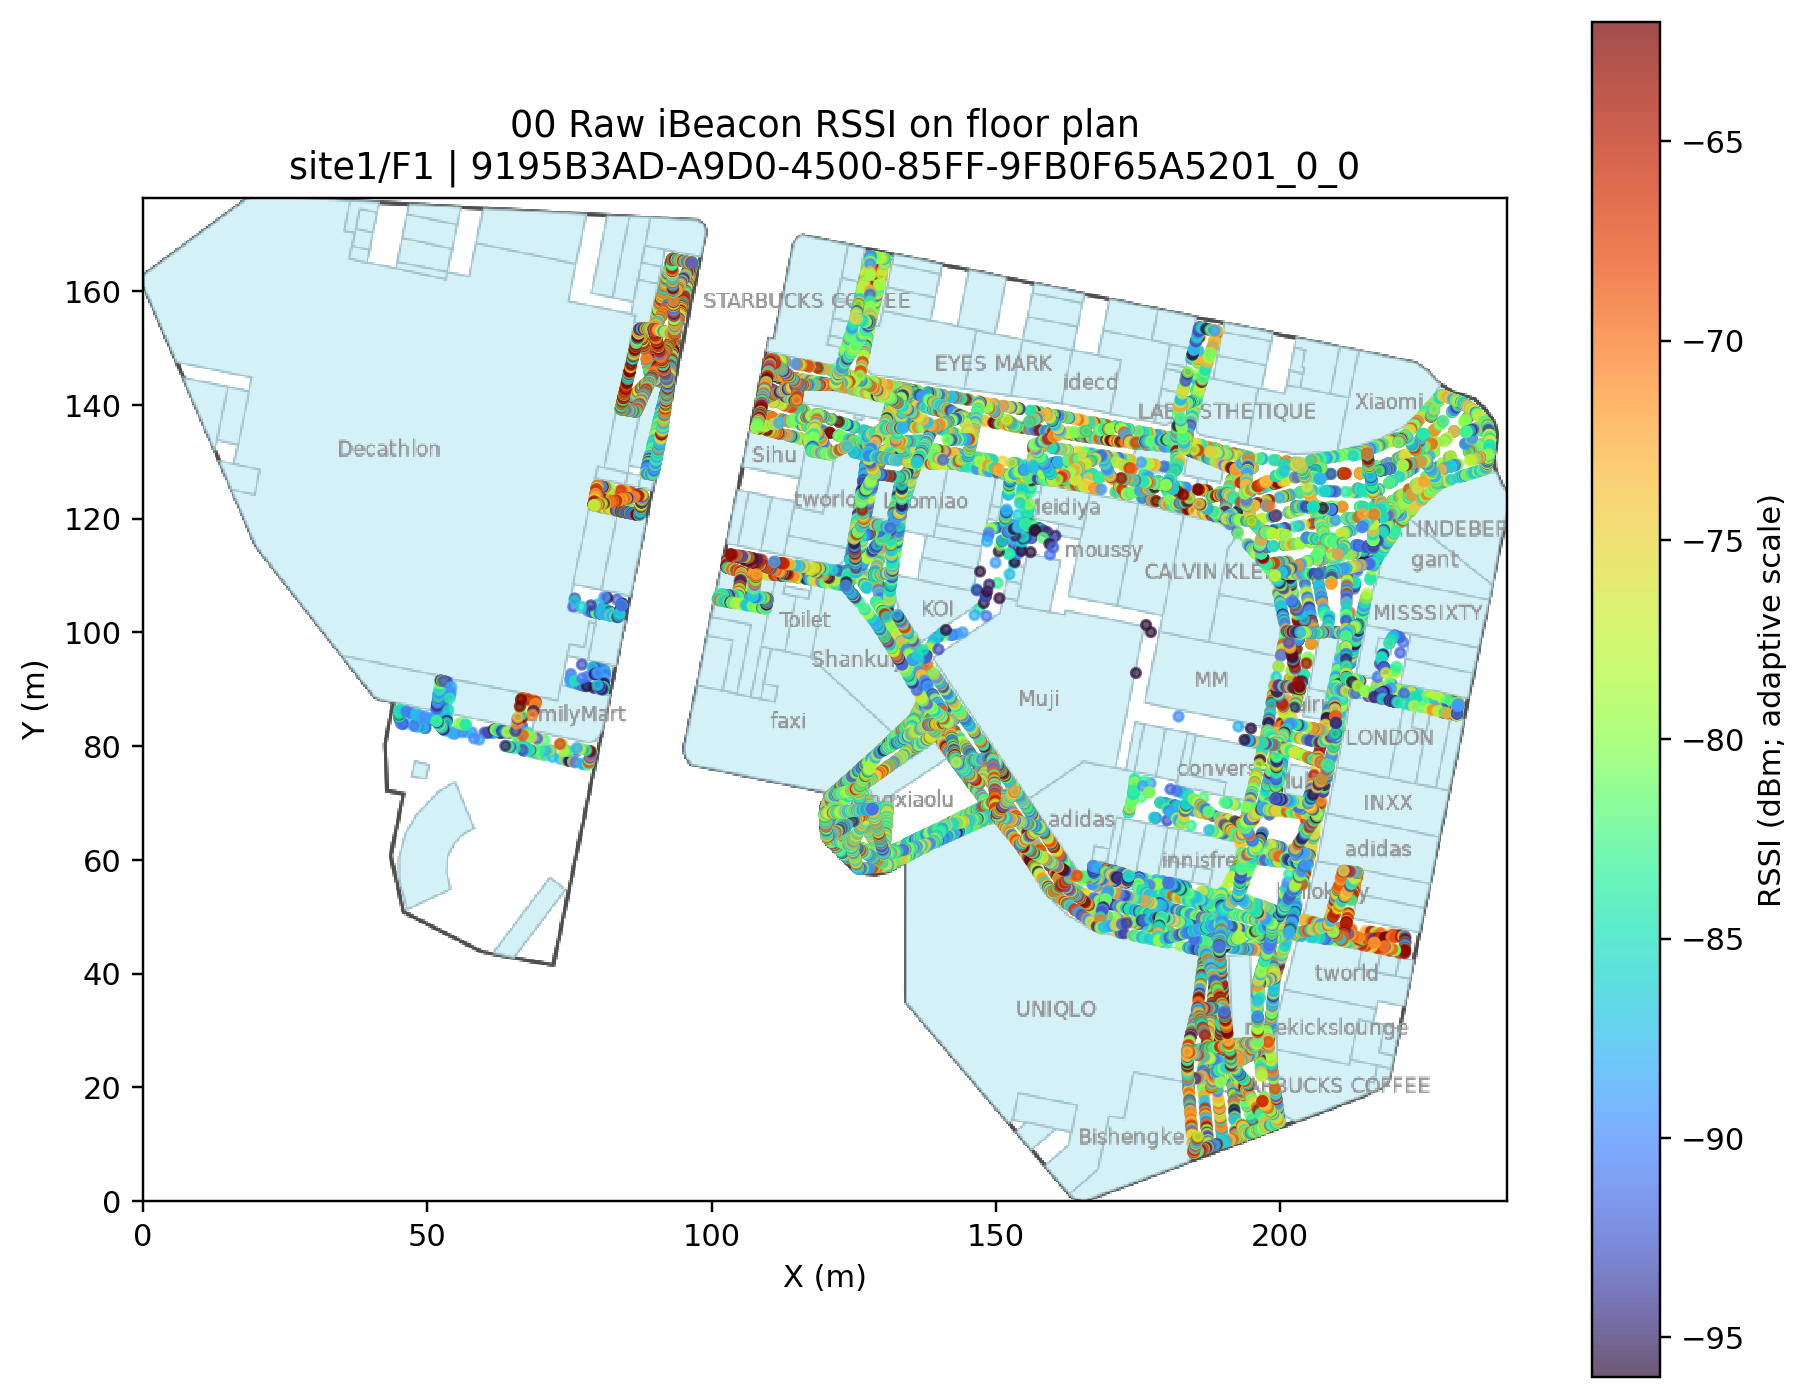

### 01 Raw Rssi Scatter

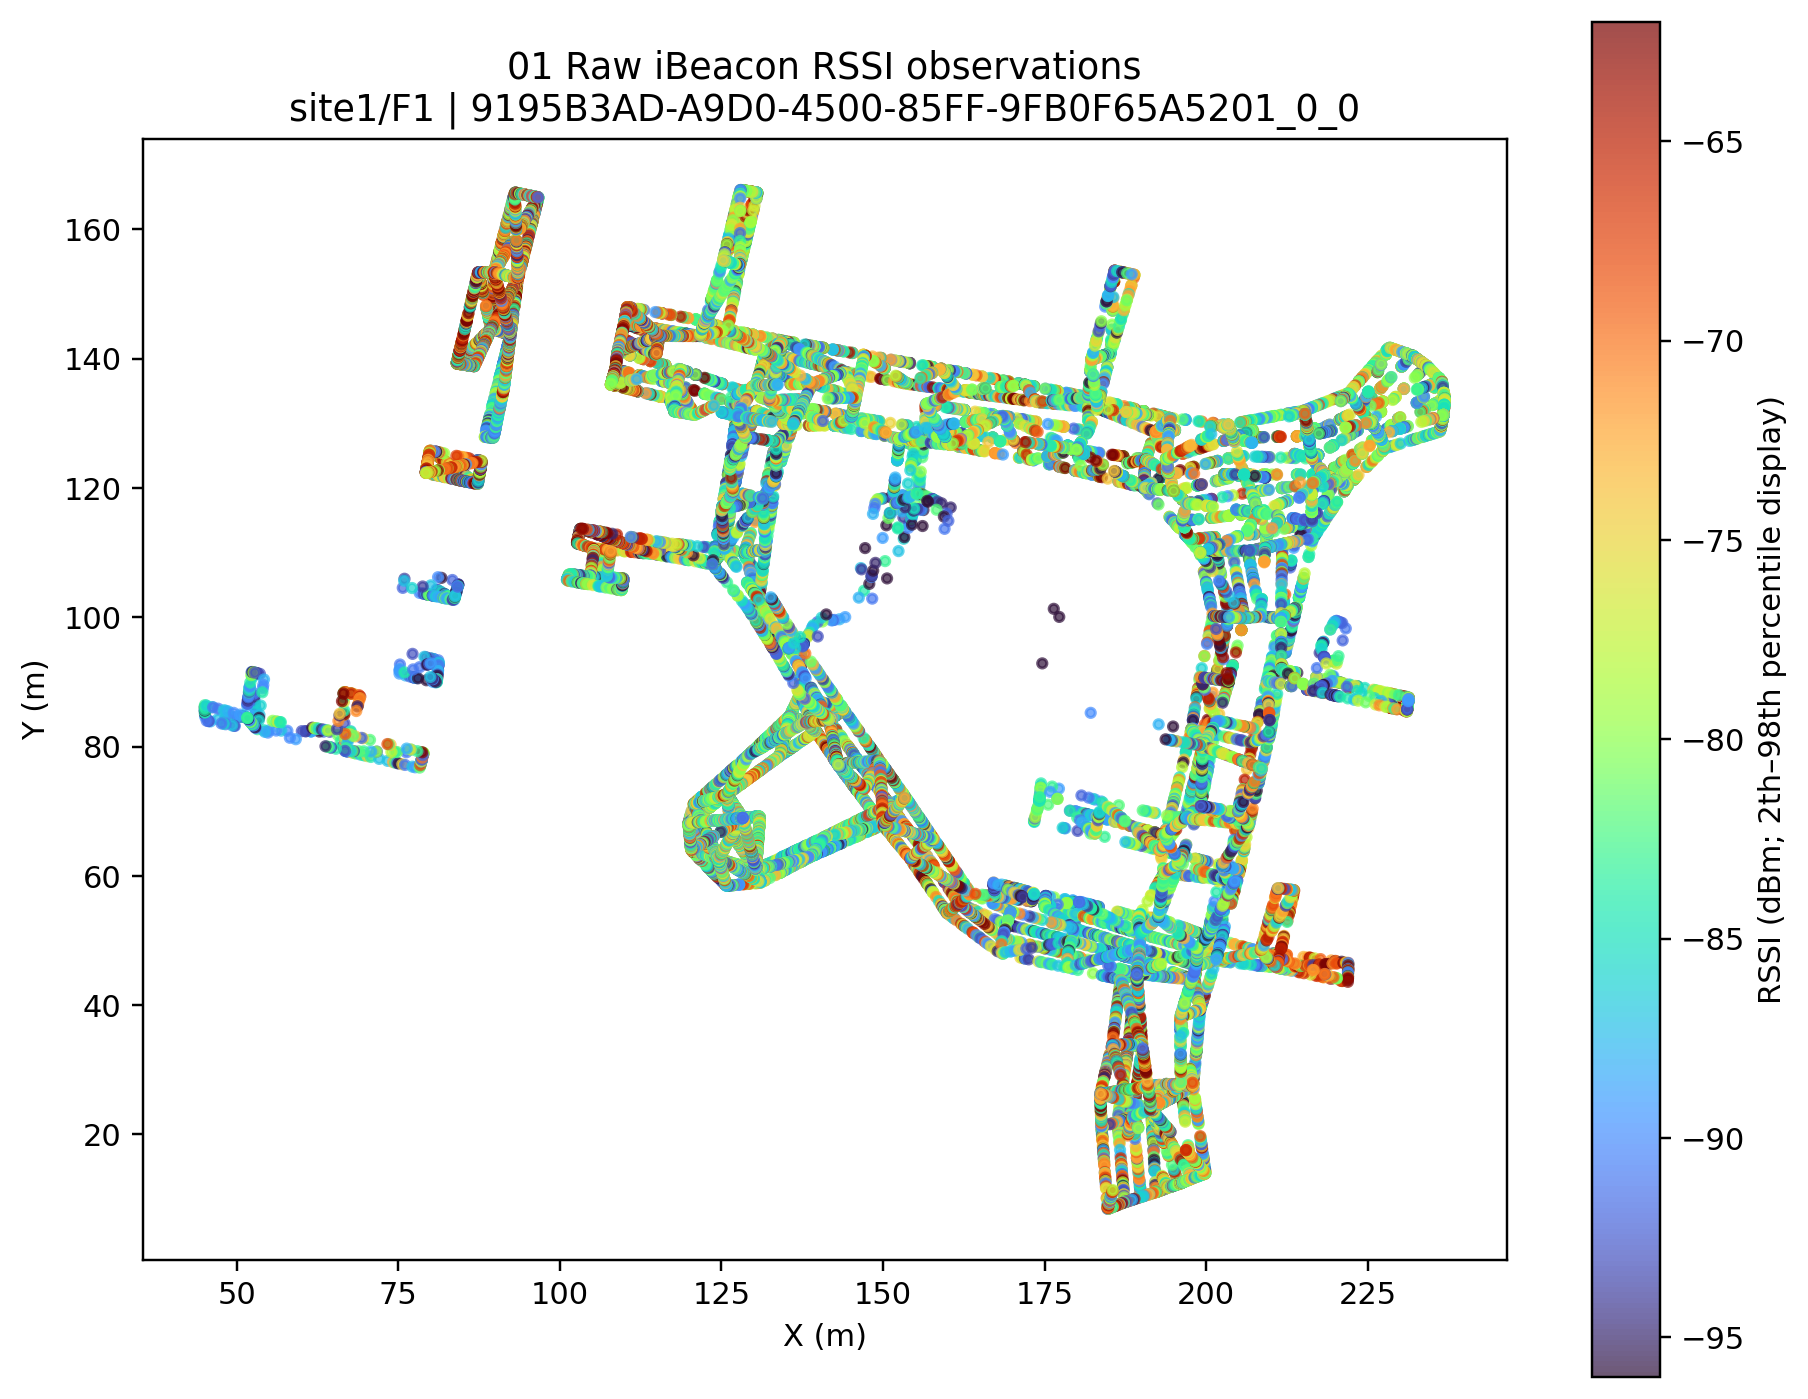

### 02 Observed Cell Median

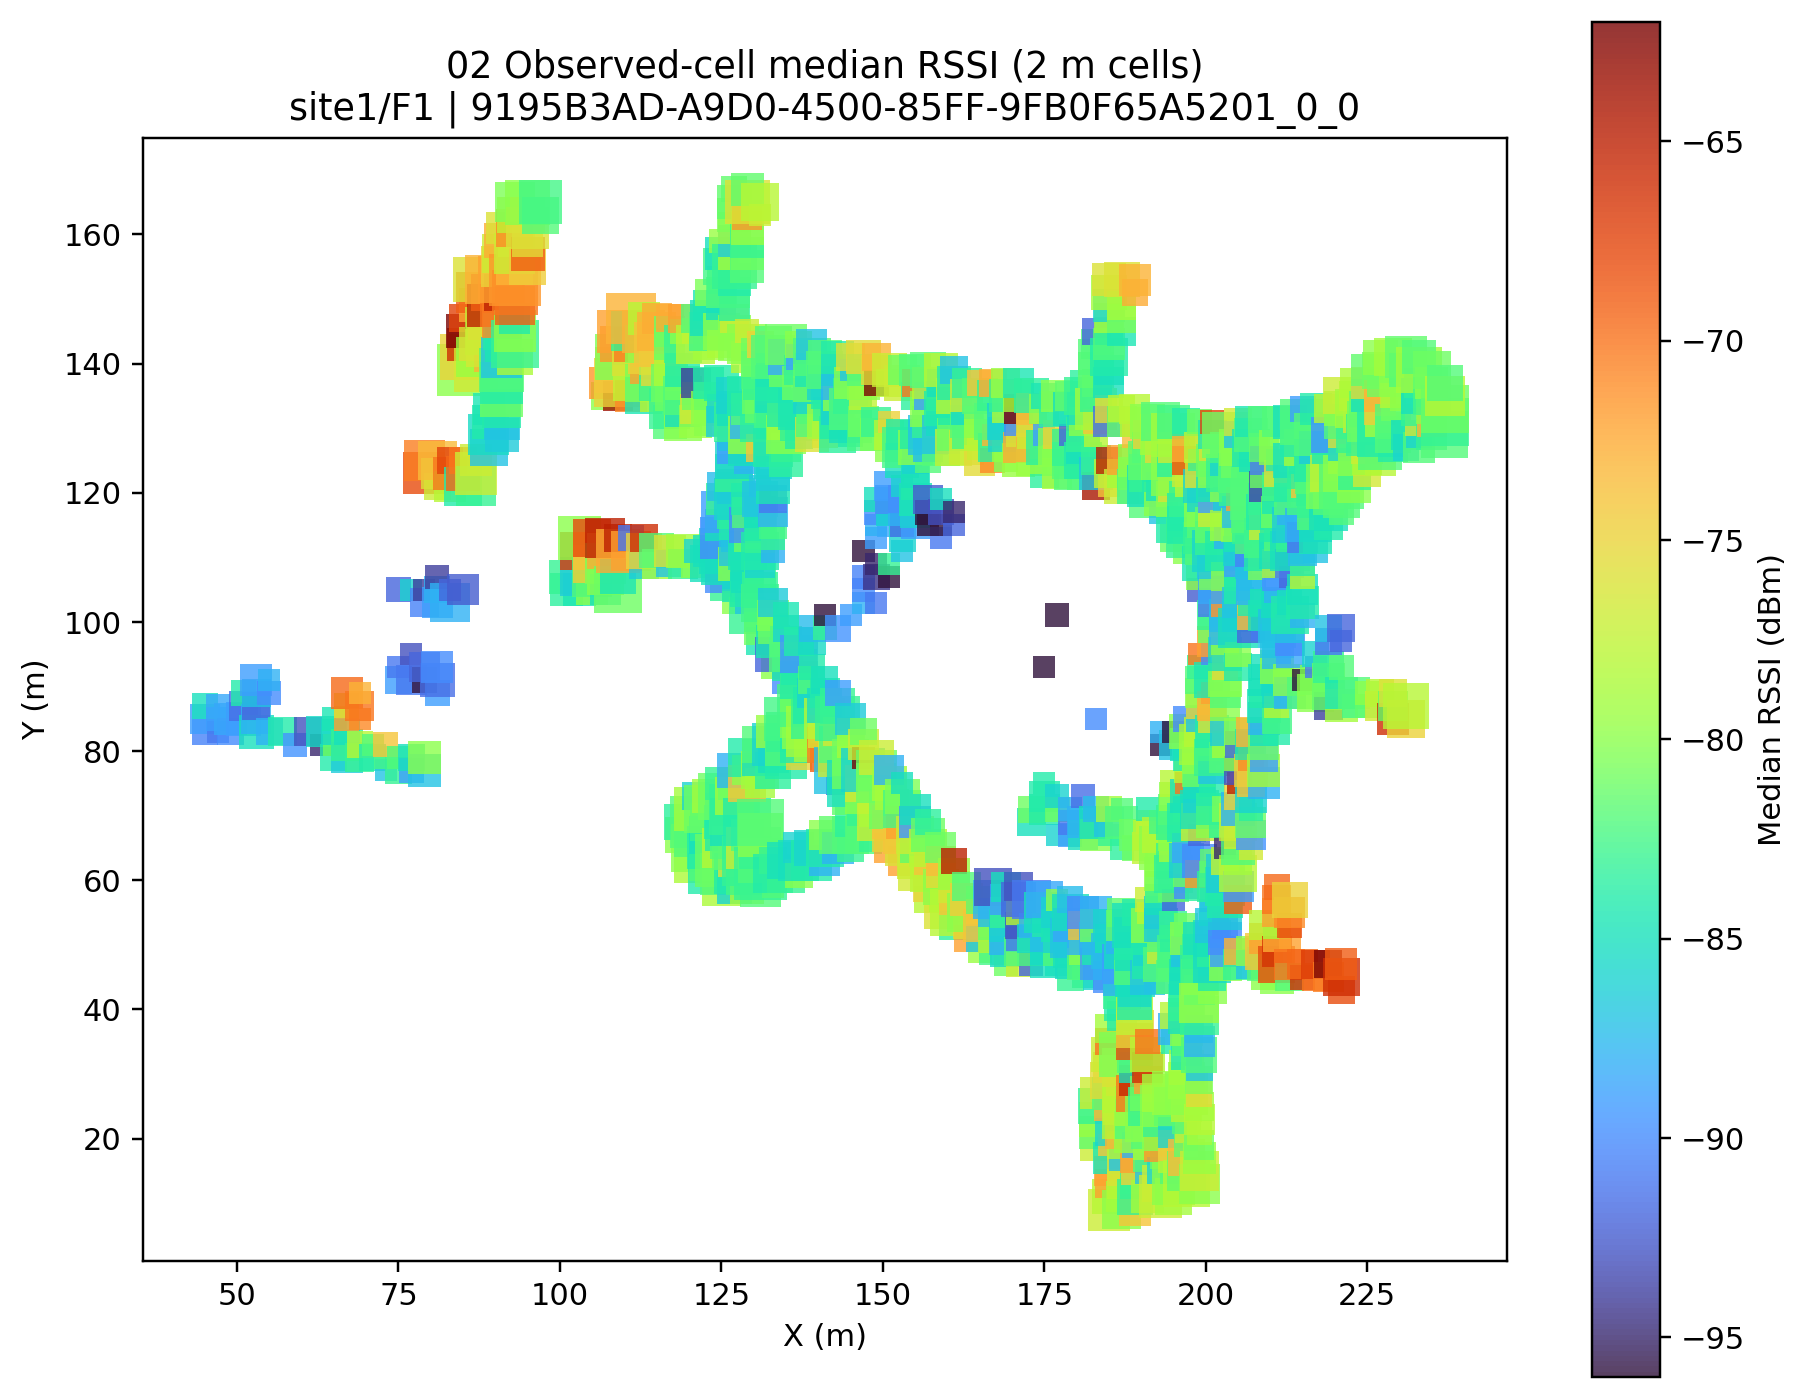

### 03 Idw Heatmap

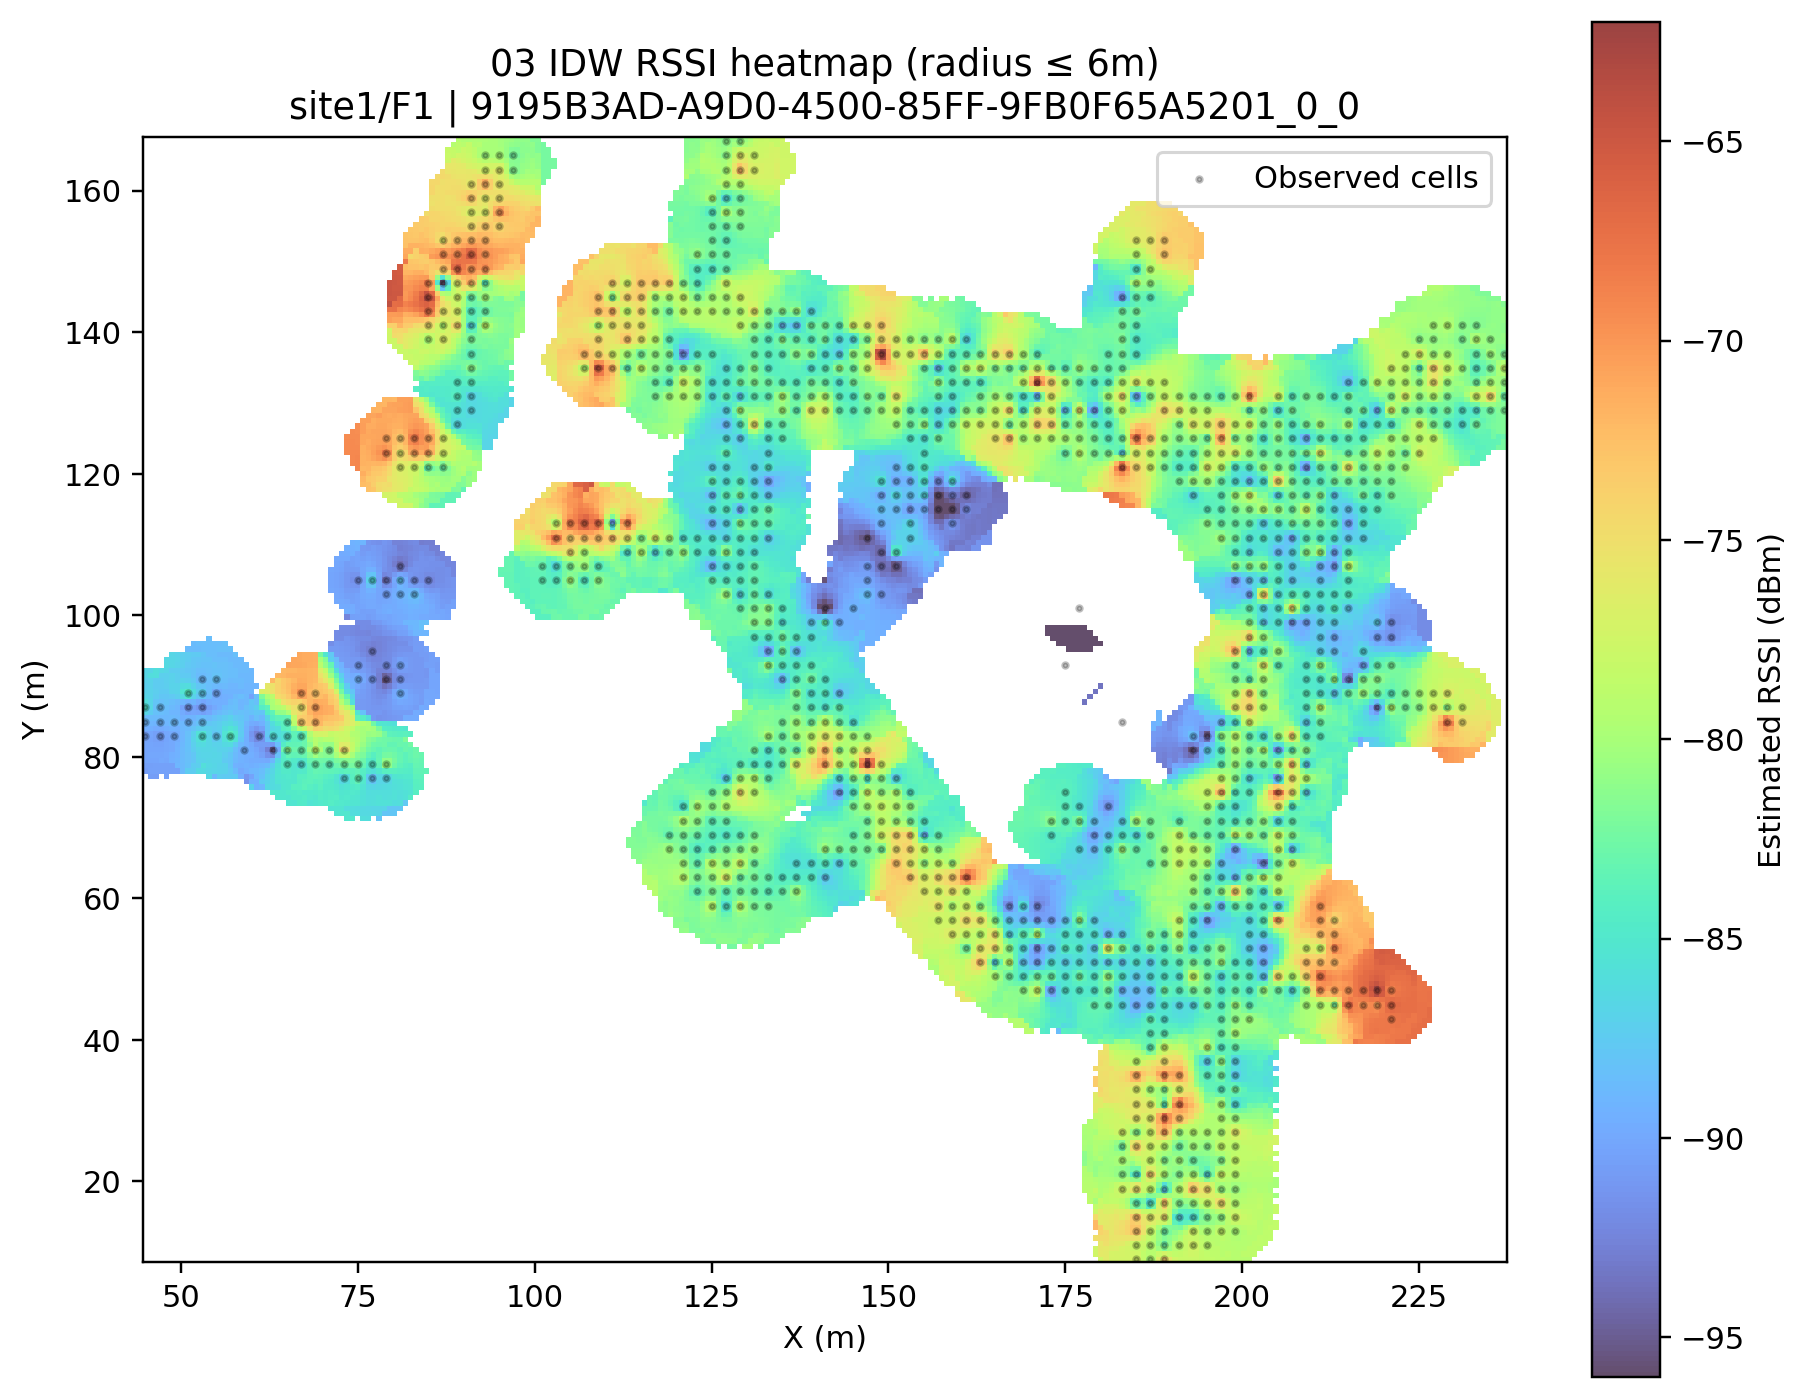

### 04 Spatial Measurement Density

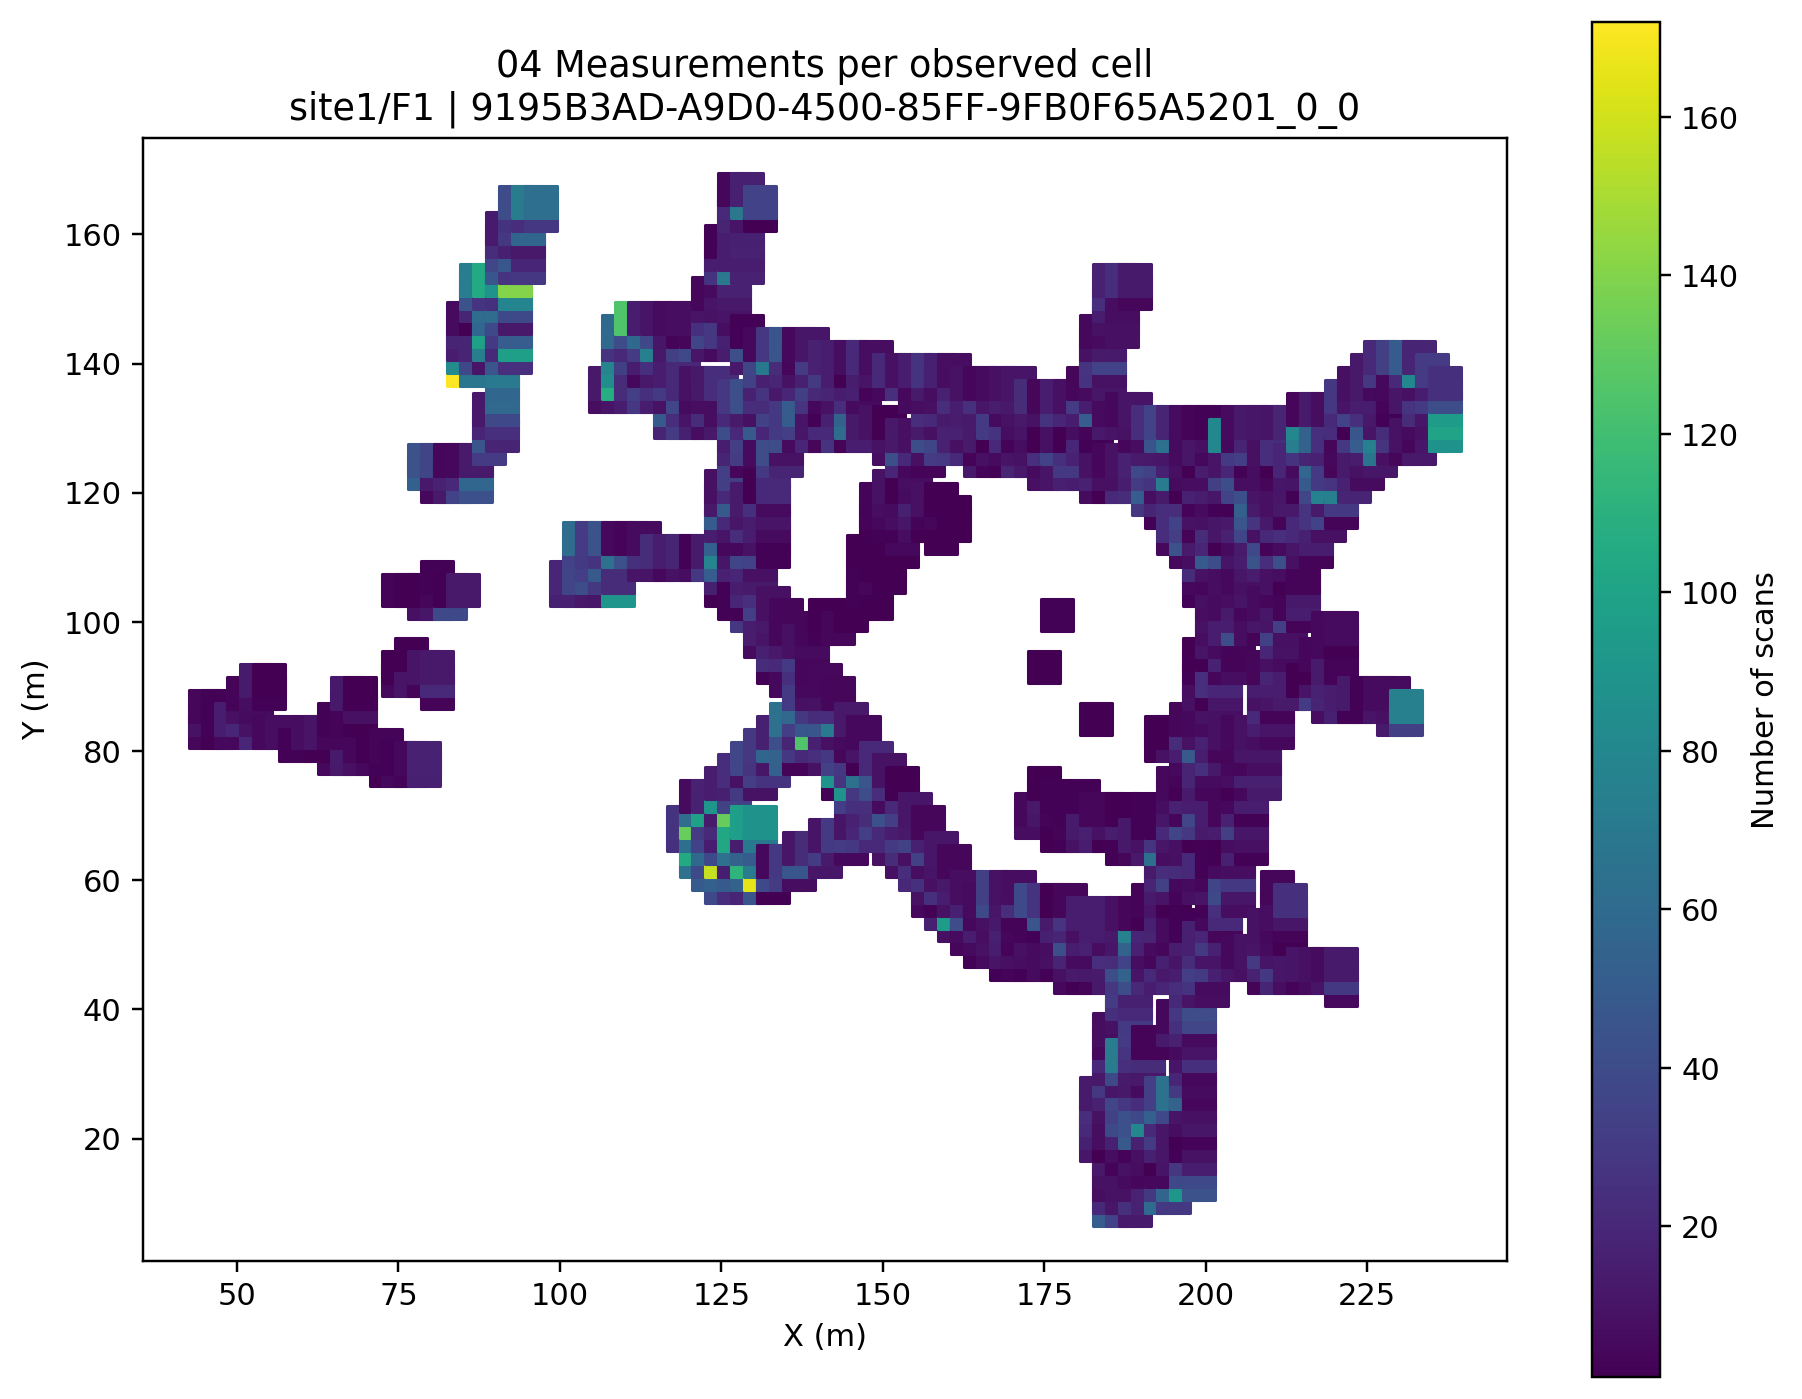

### 05 Spatial Variability

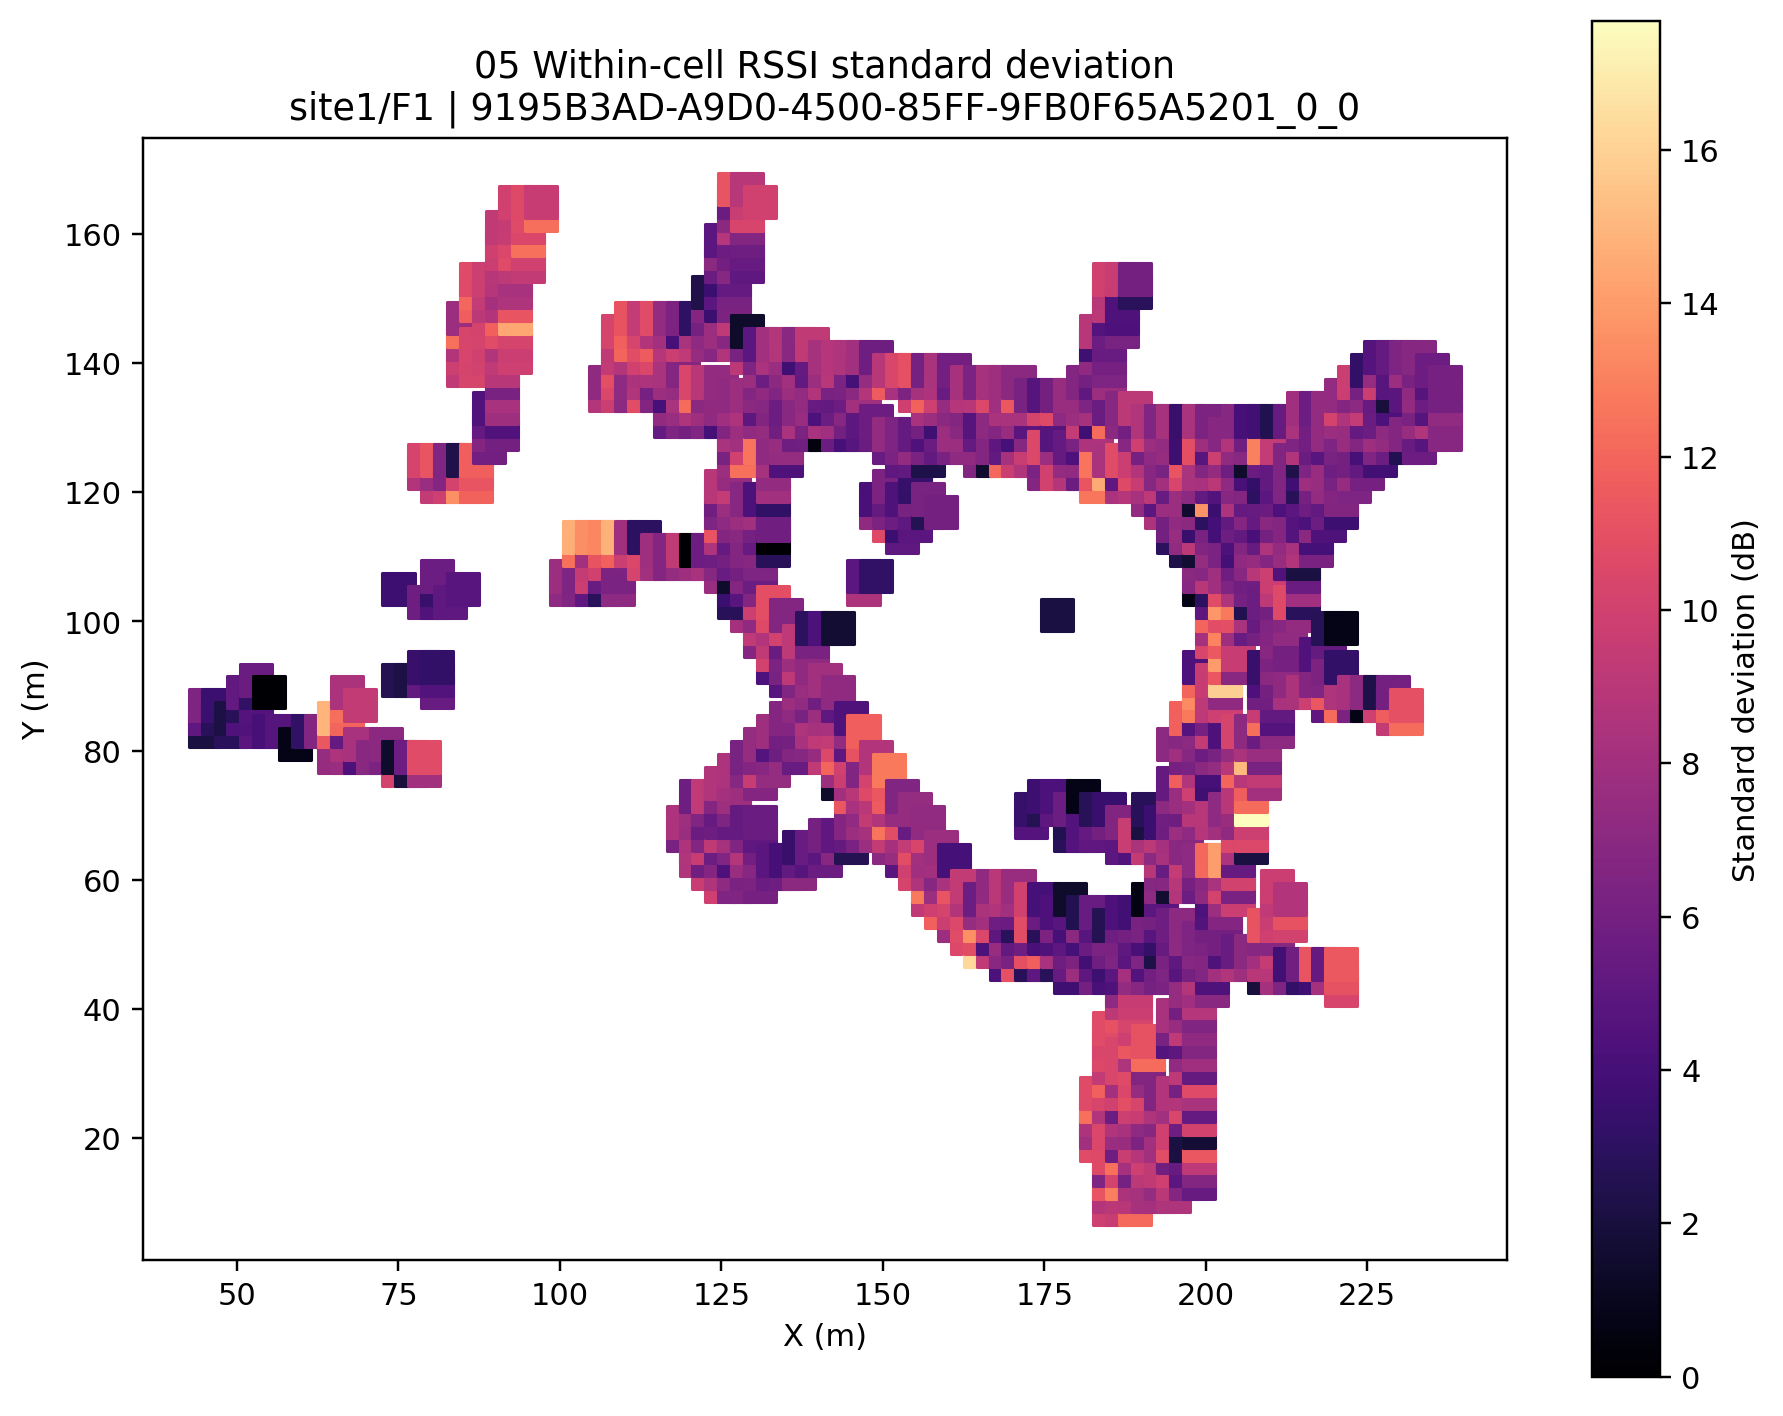

### 06 Rssi Histogram

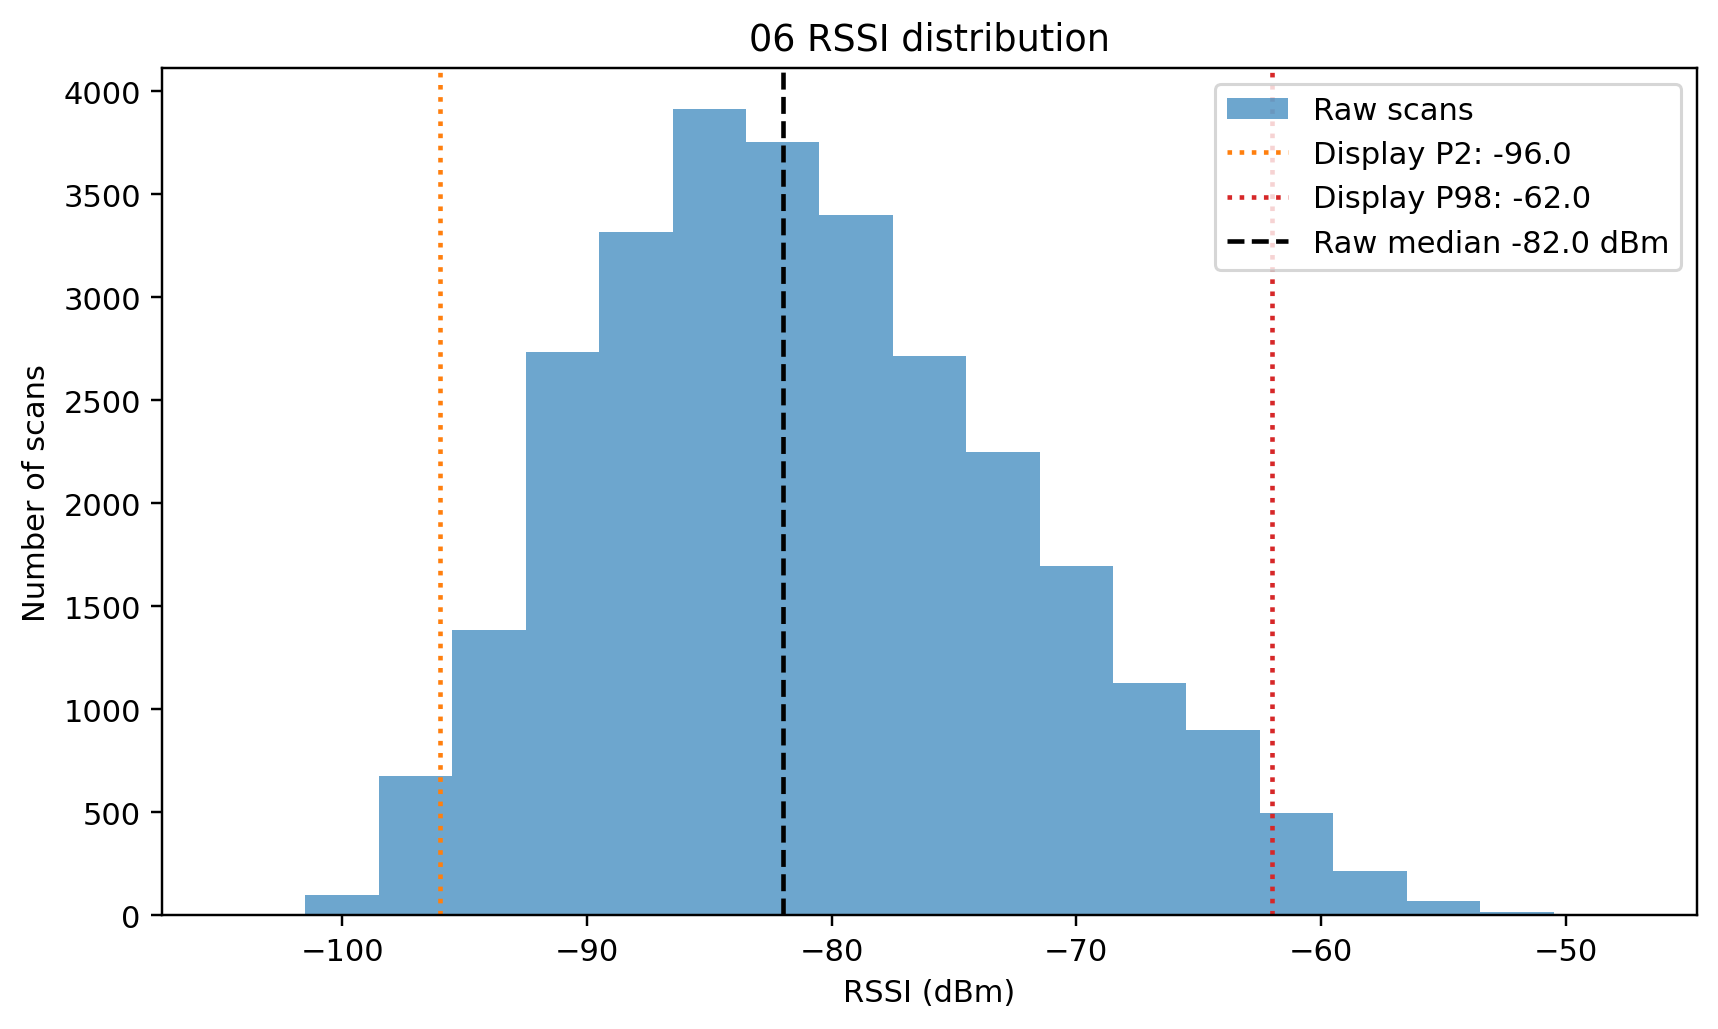

### 07 Rssi Over Time

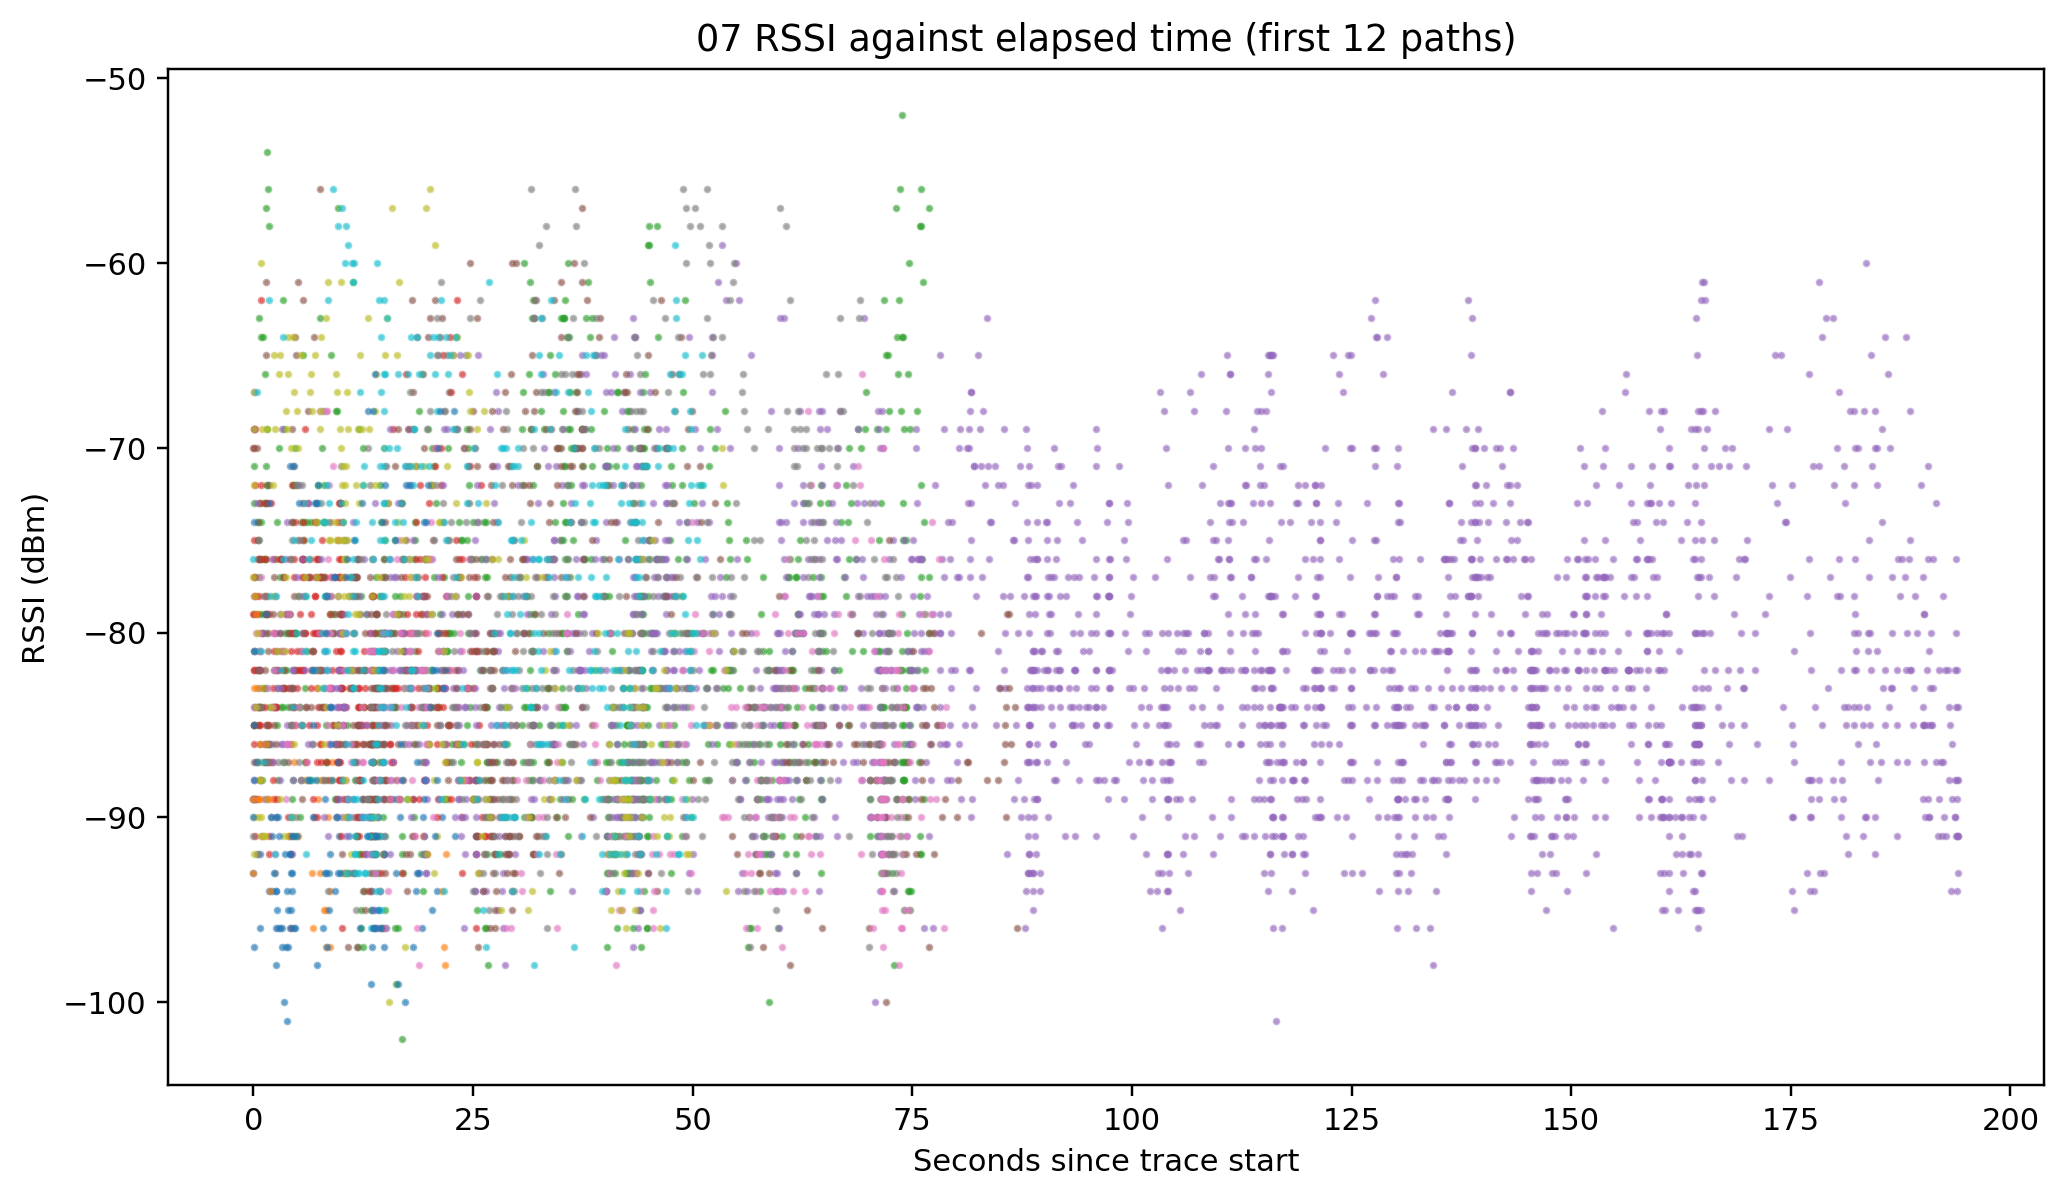

In [26]:
from IPython.display import display, Image, Markdown
PREVIEW_SITE = "site1"
PREVIEW_FLOOR = "F1"
if PREVIEW_SITE and PREVIEW_FLOOR:
    preview_dir = OUTPUT_ROOT / PREVIEW_SITE / PREVIEW_FLOOR
    image_paths = sorted(preview_dir.glob('[0-9][0-9]_*.png'))
    if not image_paths:
        print(f'No image files found at {preview_dir}')
    for image_path in image_paths:
        display(Markdown(f'### {image_path.stem.replace("_", " ").title()}'))
        display(Image(filename=str(image_path), width=800))

,site,floor,beacon_id,all_usable_scans,selected_scans,selected_paths,all_beacons,observed_cells,observed_area_m2_approx,rssi_mean_dbm,rssi_median_dbm,rssi_std_db,rssi_min_dbm,rssi_max_dbm,rssi_p05_dbm,rssi_p95_dbm,median_nearest_waypoint_gap_ms,selection_mode,status,error
0,site1,B1,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,29345,24338,152,55,1252,5008.0,-80.070959,-80.0,8.673125,-104.0,-51.0,-94.00,-65.00,1536.0,site_wide,success,NaN
1,site1,F1,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,29413,28780,119,20,1503,6012.0,-80.868867,-82.0,8.767002,-103.0,-49.0,-94.00,-65.00,1589.0,site_wide,success,NaN
2,site1,F2,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,27078,26216,119,15,1279,5116.0,-81.506904,-82.0,8.231369,-103.0,-52.0,-94.00,-66.00,1815.0,site_wide,success,NaN
3,site1,F3,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,20182,18564,114,13,1110,4440.0,-81.105958,-82.0,9.019921,-103.0,-50.0,-94.00,-64.00,1658.0,site_wide,success,NaN
4,site1,F4,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0,14542,10211,108,12,1036,4144.0,-83.145823,-84.0,8.325208,-103.0,-52.0,-95.00,-67.00,1540.0,site_wide,success,NaN
5,site2,B1,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,1996,678,58,27,351,1404.0,-83.883481,-85.0,9.327284,-102.0,-53.0,-97.00,-66.00,1420.5,site_wide,success,NaN
6,site2,F1,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,3719,477,56,23,248,992.0,-93.127883,-93.0,3.870053,-103.0,-82.0,-99.00,-86.80,1501.0,site_wide,success,NaN
7,site2,F2,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,304,74,10,8,52,208.0,-92.202703,-93.0,4.716569,-102.0,-78.0,-98.00,-82.65,1576.5,site_wide,success,NaN
8,site2,F3,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,225,64,6,11,45,180.0,-91.906250,-93.0,4.746657,-99.0,-75.0,-98.85,-84.30,1774.0,site_wide,success,NaN
9,site2,F4,FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418,229,41,5,11,30,120.0,-92.365854,-93.0,4.825744,-102.0,-81.0,-99.00,-84.00,1245.0,site_wide,success,NaN


,value
site,site1
floor,F1
beacon_id,9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0
all_usable_scans,29413
selected_scans,28780
selected_paths,119
all_beacons,20
observed_cells,1503
observed_area_m2_approx,6012.0
rssi_mean_dbm,-80.868867


,ix,iy,median_rssi,mean_rssi,std_rssi,count,n_paths,x_m,y_m
0,22,41,-90.5,-90.500000,2.081666,4,1,45.0,83.0
1,22,42,-89.0,-89.555556,5.174725,9,2,45.0,85.0
2,22,43,-85.0,-87.500000,6.454972,4,2,45.0,87.0
3,23,41,-91.0,-91.000000,NaN,1,1,47.0,83.0
4,23,42,-89.0,-89.000000,2.828427,2,2,47.0,85.0
5,23,43,-88.5,-88.500000,3.535534,2,1,47.0,87.0
6,24,41,-90.0,-89.400000,2.880972,5,1,49.0,83.0
7,24,42,-88.5,-88.357143,2.169975,14,2,49.0,85.0
8,25,42,-89.0,-89.526316,4.363592,19,2,51.0,85.0
9,25,43,-91.5,-92.125000,2.799872,8,1,51.0,87.0


Global figures:


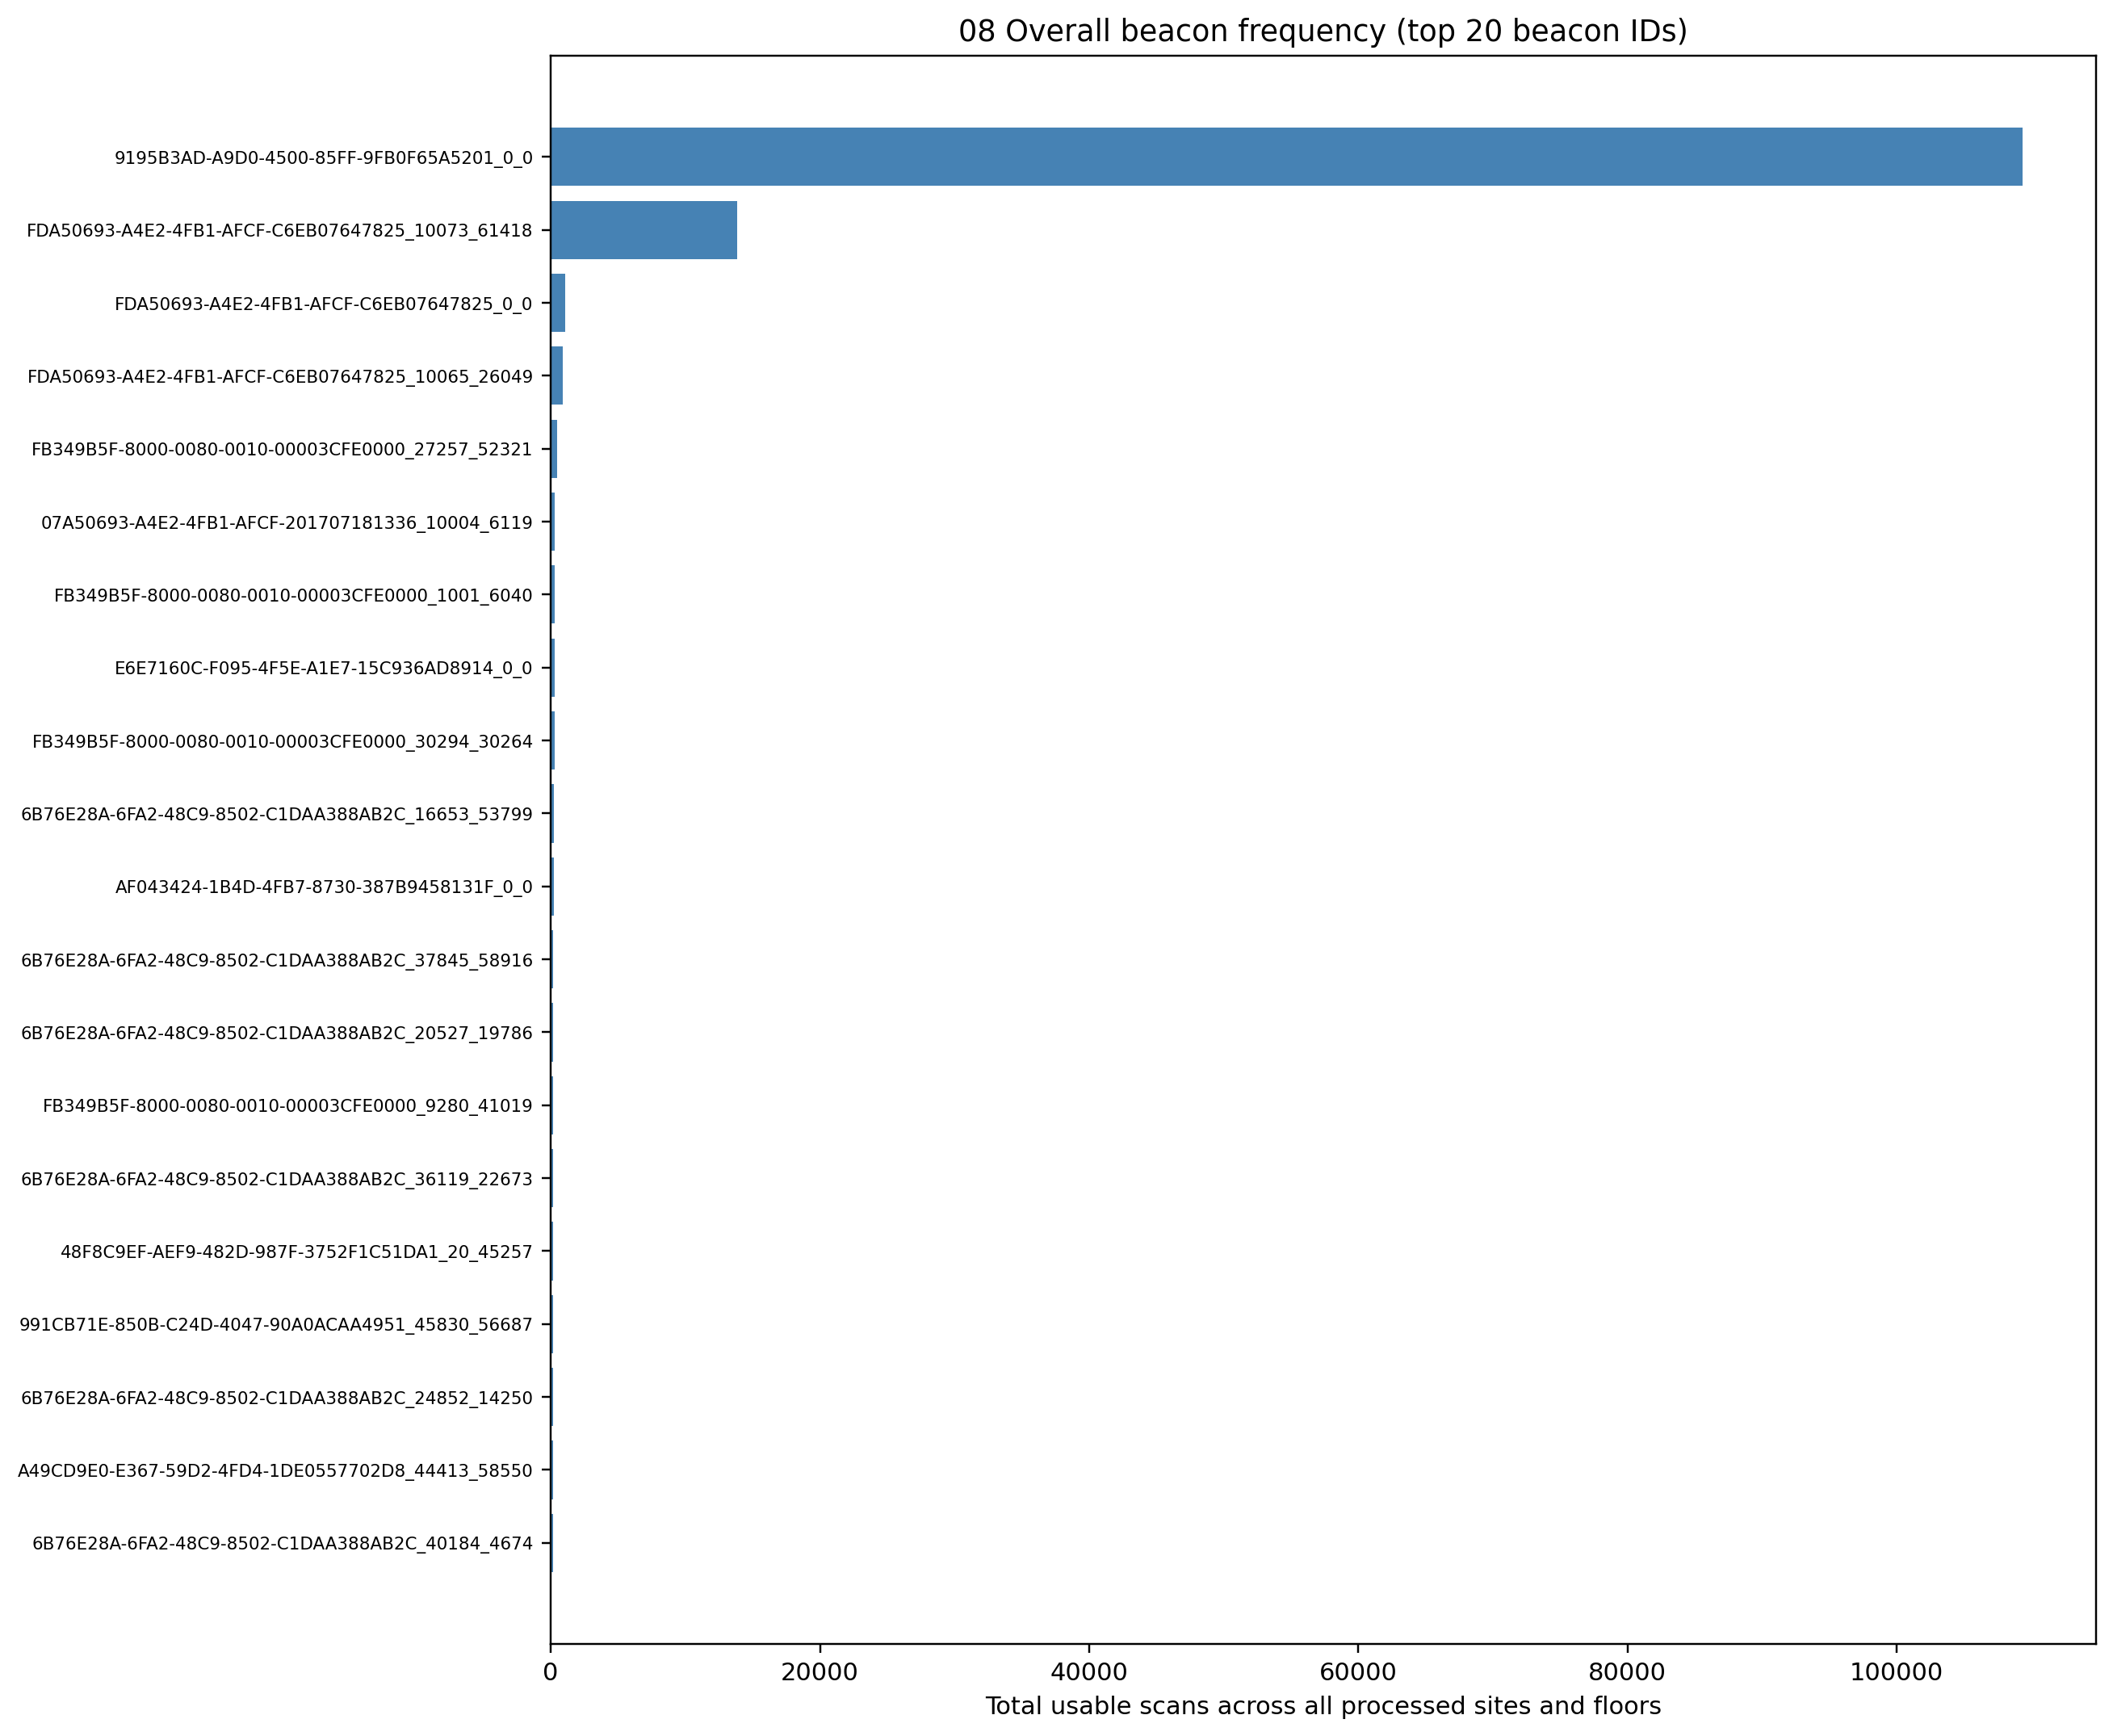

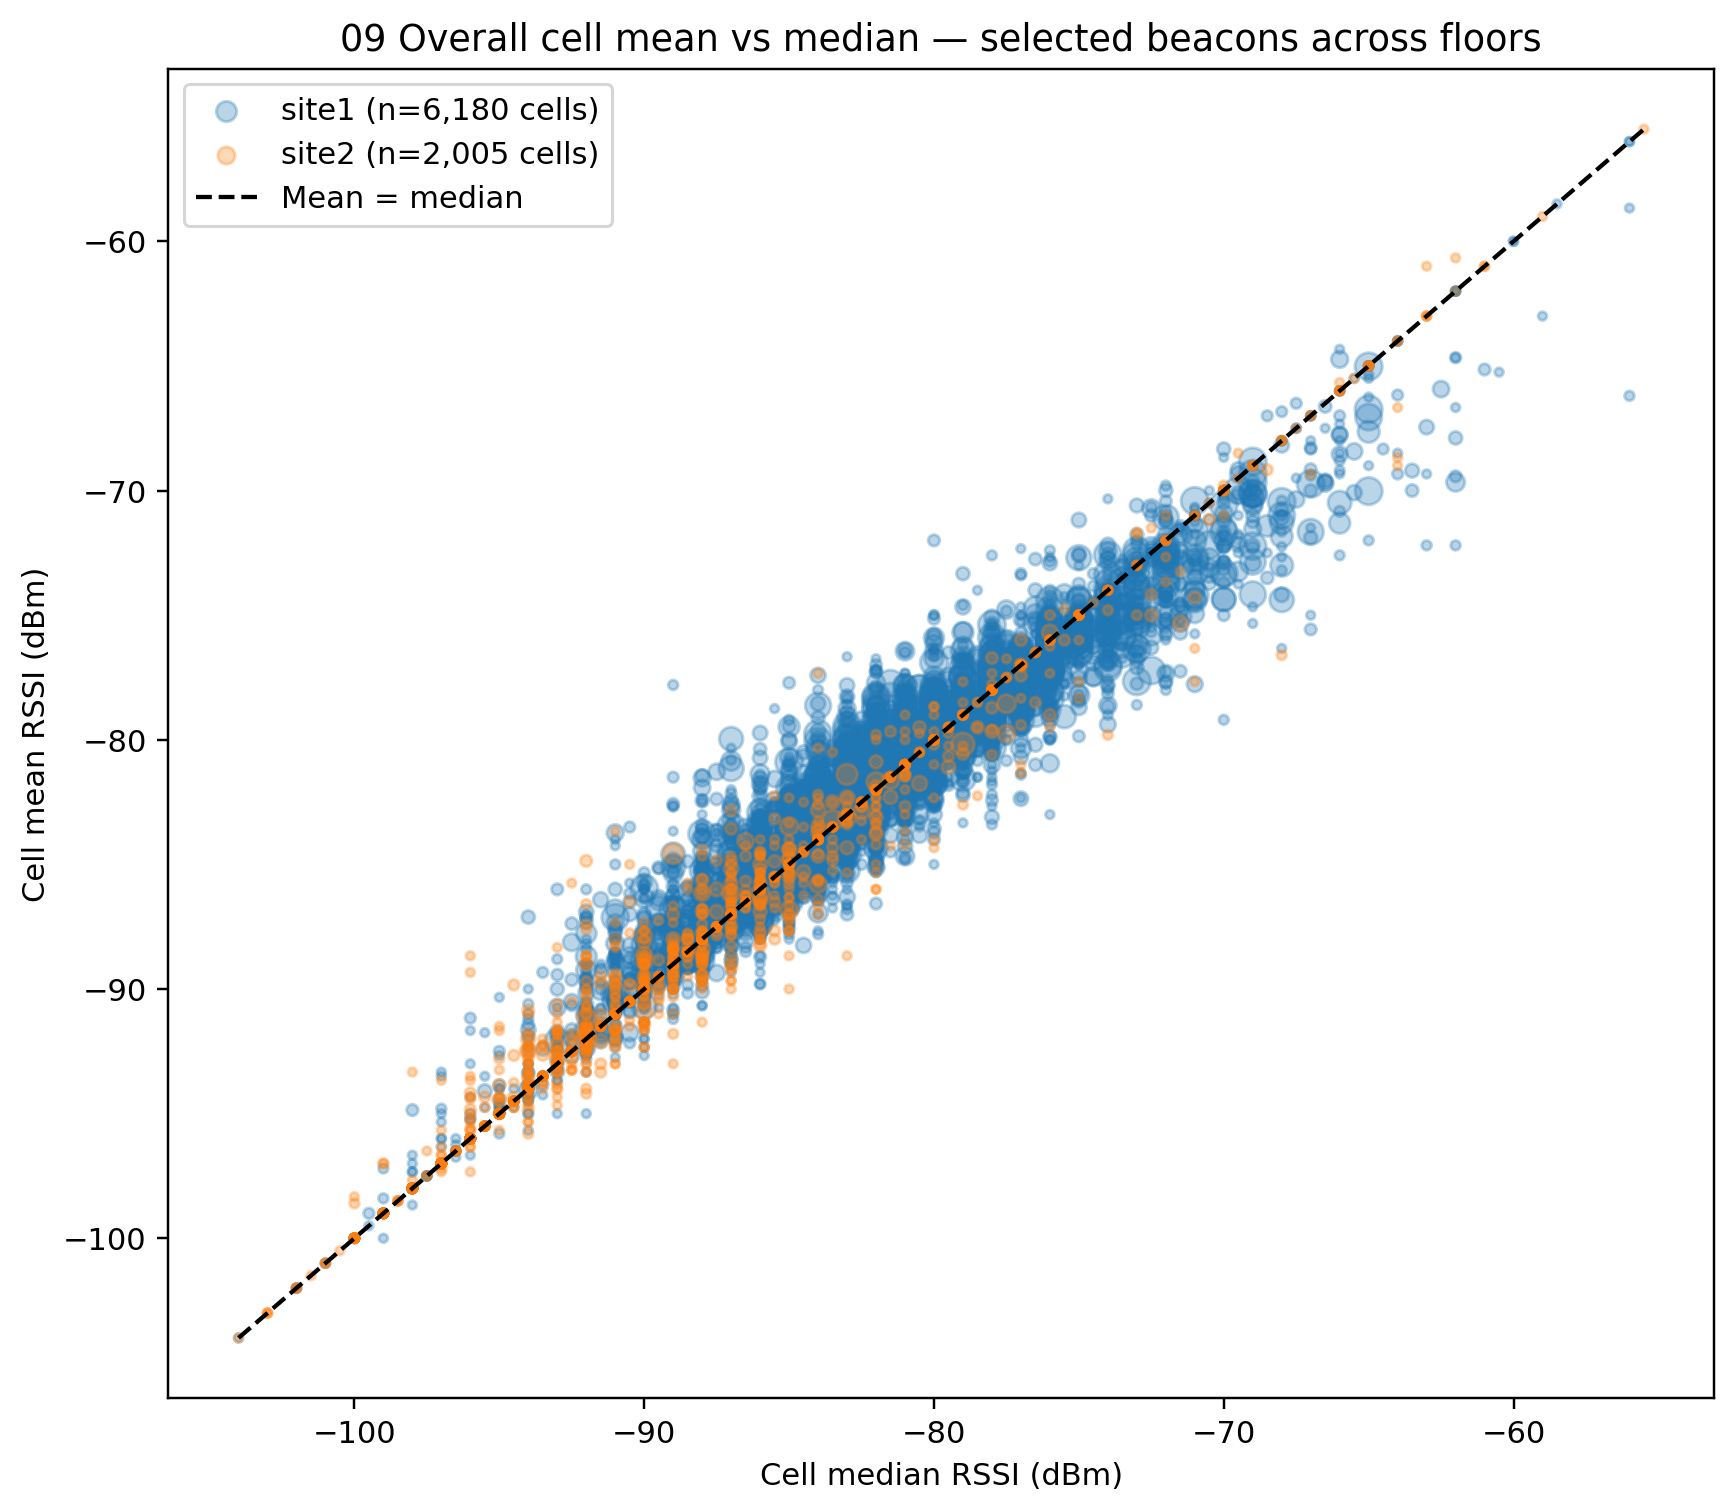

In [27]:
from IPython.display import display
display(pd.read_csv(OUTPUT_ROOT / 'all_floors_summary.csv'))
folder = OUTPUT_ROOT / 'site1' / 'F1'
if (folder / 'summary.json').exists():
    summary = json.loads((folder / 'summary.json').read_text(encoding='utf-8'))
    display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))
    display(pd.read_csv(folder / 'beacon_spatial_cells.csv').head(20))

print('Global figures:')
for filename in ['08_beacon_frequency_global.png', '09_median_vs_mean_global.png']:
    img = OUTPUT_ROOT / filename
    if img.exists():
        display(Image(filename=str(img), width=900))